# Online Retail II — Exploratory Data Analysis

## Project Overview

This project analyzes the Online Retail II dataset, covering retail transactions from December 2009 to December 2011.

The objective is to understand business performance through sales trends, product demand, customer purchasing behavior, and revenue concentration.

The analysis includes data inspection, data cleaning, exploratory data analysis, and business-oriented recommendations. Gross Sales, cancellations, and Net Sales are examined separately to provide a more accurate interpretation of recorded revenue.

### Business Questions

1. How did sales performance evolve over time?
2. Which products generated the highest revenue and sales volume?
3. Who were the highest-value customers, and how did their purchasing behaviors differ?
4. Which products were most frequently purchased by high-value customers?
5. How concentrated was revenue among high-value customers, and how much did they contribute to best-selling products?

### Tools

Python, Pandas, Matplotlib, and Jupyter Notebook.

### Dataset Source

The dataset used in this project is **Online Retail II**, provided by the UCI Machine Learning Repository.

- **Creator:** Daqing Chen
- **Source:** https://archive.ics.uci.edu/dataset/502/online+retail+ii
- **DOI:** https://doi.org/10.24432/C5CG6D
- **License:** Creative Commons Attribution 4.0 International (CC BY 4.0)

The dataset is used for educational and portfolio purposes, with attribution to its original creator and repository.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



### Dataset Location and Excel Structure

In [2]:
file_path = "../data/raw/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

### Initial Data Inspection

Load a small sample of the 2009-2010 worksheet to inspect the dataset structure and understand how the variables are organized.

In [3]:
sample_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010",
    nrows=5
)

sample_2009_2010

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


### Variable Description

- **Invoice:** Invoice number. If this code starts with the letter "C", it indicates a cancellation.
- **StockCode:** Product (item) code. A number uniquely assigned to each distinct product.
- **Description:** Product (item) name.
- **Quantity:** The quantity of each product (item) per transaction.
- **InvoiceDate:** Invoice date and time. The day and time when a transaction was generated.
- **Price:** Unit price. Product price per unit in sterling (£).
- **Customer ID:** Customer number, uniquely assigned to each customer.
- **Country:** Country name. The country where the customer resides.

### Initial Observations

- Each row represents a product (item) within a transaction, not necessarily an entire order.
- The same invoice can contain multiple different products.
- Price represents the unit price, not the total value of the line.
- Invoices starting with "C" represent cancellations and will require attention during data cleaning.
- Many customers are wholesalers, which may help explain transactions with relatively large quantities.

### Dataset Size — 2009-2010

Load the complete 2009-2010 worksheet to inspect the size of the dataset.

In [4]:
retail_2009_2010 = pd.read_excel(
    excel_file,
    sheet_name="Year 2009-2010",
)
retail_2009_2010.shape

(525461, 8)

### Dataset Size — 2010-2011

Load the complete 2010-2011 worksheet to inspect the size of the dataset.

In [5]:
retail_2010_2011 = pd.read_excel(
    excel_file,
    sheet_name='Year 2010-2011',
)
retail_2010_2011.shape

(541910, 8)

### Dataset Size — Initial Observation

- The 2009-2010 worksheet contains 525,461 rows and 8 columns.
- The 2010-2011 worksheet contains 541,910 rows and 8 columns.
- Both worksheets have the same number of variables.
- The 2010-2011 period contains 16,449 more transaction-item records than 2009-2010. This difference alone does not indicate higher sales or a greater number of orders.

### Data Types and Missing Values

Inspect the structure, data types, and non-null counts of each variable.

#### 2009-2010 Dataset

In [6]:
retail_2009_2010.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


### Observations

- The 2009-2010 dataset contains 525,461 rows and 8 columns.
- The `Description` variable contains 2,928 missing values (525,461 - 522,533).
- The `Customer ID` variable contains 107,927 missing values (525,461 - 417,534).
- The `Customer ID` variable has a `float64` data type. Since it represents an identifier rather than a numerical measurement, we will investigate this later.
- `InvoiceDate` was correctly recognized by Pandas as a datetime variable.

#### 2010-2011 Dataset

In [7]:
retail_2010_2011.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


#### Observations

- The 2010-2011 dataset contains 541,910 rows and 8 columns.
- The `Description` variable contains 1,454 missing values (541,910 - 540,456).
- The `Customer ID` variable contains 135,080 missing values (541,910 - 406,830).
- The `Customer ID` variable has a `float64` data type. Since it represents an identifier rather than a numerical measurement, we will investigate this later.
- `InvoiceDate` was correctly recognized by Pandas as a datetime variable.

### Missing Values Analysis

Quantify the missing values to better understand their impact on the dataset. We will analyze both the absolute number and the percentage of missing values.

#### 2009-2010 Dataset

In [8]:
retail_2009_2010["Customer ID"].isna().sum()

np.int64(107927)

In [9]:
retail_2009_2010["Customer ID"].isna().sum() / len(retail_2009_2010) * 100

np.float64(20.53948818275762)

In [10]:
retail_2009_2010.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [11]:
(retail_2009_2010.isna().sum() / len(retail_2009_2010) * 100).round(2)

Invoice         0.00
StockCode       0.00
Description     0.56
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    20.54
Country         0.00
dtype: float64

#### Observations

- `Description` has 2,928 missing values, representing approximately 0.56% of the dataset.
- `Customer ID` has 107,927 missing values, representing approximately 20.54% of the dataset.
- Missing `Customer ID` values are considerably more frequent and will require further investigation during data cleaning.

#### 2010-2011 Dataset


In [12]:
retail_2010_2011.isna().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [13]:
(retail_2010_2011.isna().sum() / len(retail_2010_2011) * 100).round(2)

Invoice         0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    24.93
Country         0.00
dtype: float64

#### Observations

- `Description` has 1,454 missing values, representing approximately 0.27% of the dataset.
- `Customer ID` has 135,080 missing values, representing approximately 24.93% of the dataset.
- Missing `Customer ID` values are considerably more frequent and will require further investigation during data cleaning.

### Missing Values Comparison

Compare the percentage of missing values between the 2009–2010 and 2010–2011 datasets.

In [14]:
missing_pct_2009_2010 = retail_2009_2010.isna().sum() / len(retail_2009_2010) * 100

missing_pct_2010_2011 = retail_2010_2011.isna().sum() / len(retail_2010_2011) * 100

In [15]:
missing_comparison = pd.DataFrame({
    "2009-2010": missing_pct_2009_2010,
    "2010-2011": missing_pct_2010_2011
})

missing_comparison.round(2)

,2009-2010,2010-2011
Invoice,0.00,0.00
StockCode,0.00,0.00
Description,0.56,0.27
Quantity,0.00,0.00
InvoiceDate,0.00,0.00
Price,0.00,0.00
Customer ID,20.54,24.93
Country,0.00,0.00


In [16]:
missing_comparison["Difference (pp)"] = (missing_comparison["2010-2011"] - missing_comparison["2009-2010"])

missing_comparison.round(2)

,2009-2010,2010-2011,Difference (pp)
Invoice,0.00,0.00,0.00
StockCode,0.00,0.00,0.00
Description,0.56,0.27,-0.29
Quantity,0.00,0.00,0.00
InvoiceDate,0.00,0.00,0.00
Price,0.00,0.00,0.00
Customer ID,20.54,24.93,4.39
Country,0.00,0.00,0.00


#### Observations

- Missing values in `Description` decreased from approximately 0.56% in 2009–2010 to 0.27% in 2010–2011, a decrease of approximately 0.29 percentage points.
- Missing values in `Customer ID` increased from approximately 20.54% to 24.93%, an increase of approximately 4.39 percentage points.
- `Customer ID` has a substantial proportion of missing values in both periods and requires further investigation before deciding how these records should be handled.
- All other variables contain no missing values in either dataset.

## Duplicate Records Analysis

Check for duplicated rows in both datasets before deciding whether any records should be removed.

In [17]:
retail_2009_2010.duplicated().sum()

np.int64(6865)

In [18]:
retail_2009_2010.duplicated().sum() / len(retail_2009_2010) * 100

np.float64(1.306471840916833)

### Inspecting Duplicate Records

Inspect duplicated records to understand their structure before deciding whether they should be removed.

In [19]:
retail_2009_2010[
    retail_2009_2010.duplicated(keep=False)
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


#### Observations

- The 2009–2010 dataset contains 6,865 duplicated rows, representing approximately 1.31% of all records.
- These are complete duplicates, meaning that all column values are identical to another record in the dataset.
- Duplicate records should be investigated before deciding whether they should be removed.

In [20]:
retail_2010_2011.duplicated().sum()

np.int64(5268)

In [21]:
retail_2010_2011.duplicated().sum() / len(retail_2010_2011) * 100

np.float64(0.9721171412227123)

In [22]:
retail_2010_2011[
    retail_2010_2011.duplicated(keep=False)
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


#### Observations

- The 2010–2011 dataset contains 5,268 duplicated rows, representing approximately 0.97% of all records.
- As in the 2009–2010 dataset, these are complete duplicates, meaning that all column values are identical to another record.
- The proportion of duplicated records decreased from approximately 1.31% in 2009–2010 to 0.97% in 2010–2011.
- Although duplicated records are relatively uncommon in both datasets, they should be investigated before deciding whether they should be removed.

### Investigating Duplicate Transactions

Inspect specific invoices containing duplicated records to determine whether the duplicates may represent legitimate repeated purchases or duplicated records.

In [23]:
retail_2010_2011[
    retail_2010_2011["Invoice"] == 536409
].shape

(58, 8)

In [24]:
invoice_536409 = retail_2010_2011[
    retail_2010_2011["Invoice"] == 536409
]

invoice_536409[
    invoice_536409.duplicated(keep=False)
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom


#### Investigation Notes

- Invoice `536409` contains 58 transaction lines.
- Eight rows are involved in complete duplicates, corresponding to four pairs of identical records.
- The duplicated rows have identical values across all variables, including product, quantity, price, customer, and timestamp.
- However, complete duplication alone does not prove that these records are erroneous, since repeated purchases of the same product may potentially be recorded as separate transaction lines.
- Further investigation is required before deciding whether duplicate records should be removed.

### Duplicate Distribution by Invoice

Analyze how complete duplicate records are distributed across invoices in each dataset.

#### 2009–2010 Dataset

In [25]:
duplicated_2009_2010 = retail_2009_2010[
    retail_2009_2010.duplicated(keep=False)
]

duplicated_2009_2010.shape

(13283, 8)

In [26]:
duplicated_2009_2010["Invoice"].nunique()

2538

In [27]:
retail_2009_2010["Invoice"].nunique()

28816

In [28]:
duplicated_2009_2010["Invoice"].nunique()/retail_2009_2010["Invoice"].nunique() * 100

8.807606885063853

#### 2010–2011 Dataset

In [29]:
duplicated_2010_2011 = retail_2010_2011[
    retail_2010_2011.duplicated(keep=False)
]

duplicated_2010_2011.shape

(10147, 8)

In [30]:
duplicated_2010_2011["Invoice"].nunique()

1933

In [31]:
retail_2010_2011["Invoice"].nunique()

25900

In [32]:
duplicated_2010_2011["Invoice"].nunique()/retail_2010_2011["Invoice"].nunique() * 100

7.463320463320463

#### Observations

- In 2009–2010, 13,283 rows are involved in complete duplicate groups, distributed across 2,538 invoices.
- Approximately 8.81% of all invoices in 2009–2010 contain at least one complete duplicate record.
- In 2010–2011, 10,147 rows are involved in complete duplicate groups, distributed across 1,933 invoices.
- Approximately 7.46% of all invoices in 2010–2011 contain at least one complete duplicate record.
- Duplicate records are therefore present across a meaningful number of invoices in both datasets, although their prevalence decreased in 2010–2011.
- These results identify the extent of duplication but do not establish whether the duplicated records are erroneous. A decision on their treatment will be made during data cleaning.

## Numerical Variables Analysis

Analyze the distribution and summary statistics of the numerical variables to identify unusual values and patterns that may require further investigation.

### 2009–2010 Dataset

In [33]:
retail_2009_2010[["Quantity", "Price"]].describe().round(2)

,Quantity,Price
count,525461.00,525461.00
mean,10.34,4.69
std,107.42,146.13
min,-9600.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.21
max,19152.00,25111.09


#### Negative Values Investigation

Investigate negative values in `Quantity` and `Price` to understand whether they are related to cancellations, returns, adjustments, or other transaction patterns.

In [34]:
(retail_2009_2010["Quantity"] < 0).sum()

np.int64(12326)

In [35]:
(retail_2009_2010["Price"] < 0).sum()

np.int64(3)

In [36]:
retail_2009_2010[
    retail_2009_2010["Price"] < 0
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


#### Observations

- The 2009–2010 dataset contains 12,326 records with negative `Quantity`.
- Only 3 records have a negative `Price`.
- All negative-price records have the description `Adjust bad debt`, `StockCode` B, missing `Customer ID`, and `Quantity` equal to 1.
- These records appear to represent accounting adjustments rather than regular product sales.
- These records should be handled separately during data cleaning rather than automatically treated as invalid transactions.

In [37]:
retail_2009_2010[
    retail_2009_2010["Quantity"] < 0
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [38]:
retail_2009_2010["Invoice"].str.startswith("C").sum()

10206

In [39]:
(
    (retail_2009_2010["Quantity"] < 0)
    &
    (retail_2009_2010["Invoice"].str.startswith("C"))
).sum()

np.int64(10205)

In [40]:
retail_2009_2010[
    (retail_2009_2010["Quantity"] < 0)
    &
    (~retail_2009_2010["Invoice"].str.startswith("C", na=False))
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [41]:
retail_2009_2010["Invoice"].apply(type).value_counts()

Invoice
<class 'int'>    515252
<class 'str'>     10209
Name: count, dtype: int64

- The `Invoice` column contains mixed Python data types: 515,252 integer values and 10,209 string values.
- This explains why the column is represented as `object` and why string operations require additional handling.
- Most string invoices correspond to cancellation records beginning with `C`, although a small number of string invoices use other prefixes.

In [42]:
retail_2009_2010[
    (retail_2009_2010["Invoice"].apply(type) == str)
    &
    (~retail_2009_2010["Invoice"].str.startswith("C", na=False))
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


- The 10,209 string values in `Invoice` consist of 10,206 invoices beginning with `C` and 3 invoices beginning with `A`.
- The three invoices beginning with `A` correspond to `Adjust bad debt` records previously identified during the negative price analysis.
- Therefore, the mixed data types in `Invoice` reflect different transaction identifiers rather than missing invoice values.

#### Negative Quantities Outside Cancellation Invoices

Investigate records with negative quantities whose invoices do not begin with `C` to identify other types of non-sale transactions or inventory adjustments.

In [43]:
negative_non_cancelled_2009_2010 = retail_2009_2010[
    (retail_2009_2010["Quantity"] < 0)
    &
    (~retail_2009_2010["Invoice"].str.startswith("C", na=False))
]

negative_non_cancelled_2009_2010["Description"].value_counts(dropna=False).head(20)

Description
NaN            1827
?                42
damages          39
damaged          36
missing          24
dotcom            6
given away        6
smashed           5
checked           5
MIA               4
Damages           4
ebay sales        4
crushed           4
No Stock          3
Damaged           3
counted           3
check             3
discoloured       2
damages?          2
Dotcom            2
Name: count, dtype: int64

#### Observations

- There are 2,121 records with negative `Quantity` whose `Invoice` does not begin with `C`.
- Most of these records (1,827) have a missing `Description`, representing approximately 86.1% of this subset.
- Among the available descriptions, terms such as `damages`, `damaged`, `missing`, `given away`, `smashed`, `MIA`, and `No Stock` suggest that many of these records may represent inventory adjustments rather than customer cancellations.
- Variations such as `damages`, `Damages`, `damaged`, and `Damaged` also indicate inconsistent text formatting.
- These records should therefore be investigated and handled separately during data cleaning rather than automatically classified as cancelled transactions.

In [44]:
(negative_non_cancelled_2009_2010["Price"] != 0).sum()

np.int64(0)

- All 2,121 negative-quantity records outside `C` invoices have a `Price` equal to zero, further supporting the interpretation that these records are likely operational or inventory adjustments rather than regular sales transactions.

### 2010–2011 Dataset

In [45]:
retail_2010_2011[["Quantity", "Price"]].describe().round(2)

,Quantity,Price
count,541910.00,541910.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


In [46]:
retail_2010_2011[
    retail_2010_2011["Quantity"] == -80995
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [47]:
retail_2010_2011[
    retail_2010_2011["Quantity"] == 80995
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


#### Observation

- The extreme `Quantity` values of 80,995 and -80,995 correspond to the same product (`StockCode 23843`), customer, price, and country.
- Invoice `581483` records a quantity of 80,995 at 09:15, while cancellation invoice `C581484` records -80,995 only 12 minutes later.
- This strongly indicates that the extreme negative value represents a full reversal of the preceding transaction rather than an independent anomalous observation.
- These records should therefore be considered together when defining the data-cleaning strategy.

#### Negative Values Investigation

Investigate negative values in `Quantity` and `Price` to understand whether they are related to cancellations, returns, adjustments, or other transaction patterns.

In [48]:
(retail_2010_2011["Quantity"] < 0).sum()


np.int64(10624)

In [49]:
(retail_2010_2011["Price"] < 0).sum()


np.int64(2)

In [50]:

retail_2010_2011[
    retail_2010_2011["Price"] < 0
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [51]:
(
    (retail_2010_2011["Quantity"] < 0)
    &
    (retail_2010_2011["Invoice"].astype(str).str.startswith("C"))
).sum()

np.int64(9288)

In [52]:
(
    (retail_2010_2011["Quantity"] < 0)
    &
    (~retail_2010_2011["Invoice"].astype(str).str.startswith("C"))
).sum()

np.int64(1336)

In [53]:
negative_non_cancelled_2010_2011 = retail_2010_2011[
    (retail_2010_2011["Quantity"] < 0)
    &
    (~retail_2010_2011["Invoice"].astype(str).str.startswith("C"))
]
negative_non_cancelled_2010_2011["Description"].value_counts(
    dropna=False
).head(20)

Description
NaN                           862
check                         120
damages                        45
damaged                        42
?                              41
sold as set on dotcom          20
Damaged                        14
thrown away                     9
Unsaleable, destroyed.          9
??                              7
damages?                        5
wet damaged                     5
ebay                            5
smashed                         4
missing                         3
CHECK                           3
wet pallet                      3
Dotcom sales                    2
reverse 21/5/10 adjustment      2
counted                         2
Name: count, dtype: int64

In [54]:
(negative_non_cancelled_2010_2011["Price"] != 0).sum()

np.int64(0)

#### Observation

- The 2010–2011 dataset contains 10,624 records with negative `Quantity`.
- Of these, 9,288 are associated with cancellation invoices beginning with `C`, while 1,336 occur outside cancellation invoices.
- All 1,336 negative-quantity records outside `C` invoices have a `Price` equal to zero.
- Their descriptions frequently include terms such as `check`, `damages`, `damaged`, `thrown away`, `missing`, and other non-product descriptions.
- This pattern is consistent with the 2009–2010 dataset and suggests that these records are likely operational or inventory adjustments rather than regular sales transactions.

In [55]:
retail_2010_2011[
    retail_2010_2011["Price"] == 38970
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.0,15098.0,United Kingdom


In [56]:
retail_2010_2011[
    retail_2010_2011["Customer ID"] == 15098
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
222670,556442,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:22:00,4.95,15098.0,United Kingdom
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.50,15098.0,United Kingdom
222692,C556448,22502,PICNIC BASKET WICKER SMALL,-60,2011-06-10 15:39:00,4.95,15098.0,United Kingdom


In [57]:
(retail_2010_2011["StockCode"] == "M").sum()

np.int64(571)

In [58]:
retail_2010_2011[
    retail_2010_2011["StockCode"] == "M"].describe().round(2)

,Quantity,InvoiceDate,Price,Customer ID
count,571.00,571,571.00,465.00
mean,5.54,2011-06-26 23:03:50.332749,375.57,15275.19
min,-1350.00,2010-12-01 15:35:00,0.00,12352.00
25%,-1.00,2011-03-31 11:42:00,1.00,13263.00
50%,1.00,2011-07-10 12:16:00,7.95,15502.00
75%,1.00,2011-10-10 13:37:00,278.06,16928.00
max,1600.00,2011-12-09 10:28:00,38970.00,18283.00
std,120.37,NaN,1773.40,1873.73


#### Observation

- The maximum `Price` of £38,970 corresponds to a `Manual` record (`StockCode M`) associated with cancellation invoice `C556445`.
- The record is linked to customer `15098` and occurs shortly after a transaction whose total value was also £38,970, indicating that the extreme value is associated with a manual reversal rather than a regular unit price.
- `StockCode M` appears in 571 records, with a median `Price` of £7.95, while the maximum reaches £38,970, showing that manual records can contain substantial extreme values.
- These records should be treated carefully during data cleaning and revenue analysis rather than automatically classified as regular product sales or removed as errors.

### Comparison Between Periods

In [59]:
summary_2009_2010 = retail_2009_2010[
    ["Quantity", "Price"]
].describe().round(2)

summary_2010_2011 = retail_2010_2011[
    ["Quantity", "Price"]
].describe().round(2)

pd.concat(
    [summary_2009_2010, summary_2010_2011],
    axis=1,
    keys=["2009-2010", "2010-2011"]
)

2009-2010             2010-2011           
        Quantity      Price   Quantity      Price
count  525461.00  525461.00  541910.00  541910.00
mean       10.34       4.69       9.55       4.61
std       107.42     146.13     218.08      96.76
min     -9600.00  -53594.36  -80995.00  -11062.06
25%         1.00       1.25       1.00       1.25
50%         3.00       2.10       3.00       2.08
75%        10.00       4.21      10.00       4.13
max     19152.00   25111.09   80995.00   38970.00

#### Observations

- The central distributions of `Quantity` and `Price` are highly similar across both periods. The median `Quantity` is 3 in both datasets, while the median `Price` changes only slightly from £2.10 to £2.08.
- Mean values are also relatively stable, suggesting that the typical transaction-line characteristics remained broadly similar between the two periods.
- The 2010–2011 dataset contains substantially more extreme `Quantity` values, ranging from -80,995 to 80,995, compared with -9,600 to 19,152 in 2009–2010.
- These extreme values increase the variability of `Quantity` in 2010–2011 and, as shown in the previous investigation, are associated with exceptional transactions rather than typical purchasing behavior.
- Overall, the two periods show similar central patterns despite substantial differences in their extreme values.

## Categorical Variables Analysis

Analyze the distribution of categorical variables to identify dominant categories, unusual values, and patterns that may require further investigation.

### Country Analysis

#### 2009–2010 Dataset

In [60]:
retail_2009_2010["Country"].nunique()

40

In [61]:
retail_2009_2010["Country"].value_counts()

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [62]:
round(
    (retail_2009_2010["Country"] == "United Kingdom").sum()
    / len(retail_2009_2010)
    * 100,
    2
)

np.float64(92.46)

#### 2010–2011 Dataset

In [63]:
retail_2010_2011["Country"].nunique()

38

In [64]:
retail_2010_2011["Country"].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8558
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [65]:
retail_2010_2011["Country"].value_counts(
    normalize=True
).mul(100).round(2)

Country
United Kingdom          91.43
Germany                  1.75
France                   1.58
EIRE                     1.51
Spain                    0.47
Netherlands              0.44
Belgium                  0.38
Switzerland              0.37
Portugal                 0.28
Australia                0.23
Norway                   0.20
Italy                    0.15
Channel Islands          0.14
Finland                  0.13
Cyprus                   0.11
Sweden                   0.09
Unspecified              0.08
Austria                  0.07
Denmark                  0.07
Japan                    0.07
Poland                   0.06
Israel                   0.05
USA                      0.05
Hong Kong                0.05
Singapore                0.04
Iceland                  0.03
Canada                   0.03
Greece                   0.03
Malta                    0.02
United Arab Emirates     0.01
European Community       0.01
RSA                      0.01
Lebanon                  0.01
Li

#### Observations

- The `Country` variable contains 40 unique values in 2009–2010 and 38 in 2010–2011.
- Both periods are strongly concentrated in the United Kingdom, which represents 92.46% of all records in 2009–2010 and 91.43% in 2010–2011.
- The distribution therefore remains geographically concentrated across both periods, despite a small decrease of 1.03 percentage points in the United Kingdom's share.
- `Unspecified` appears as a category in both datasets, indicating that not every unique value in `Country` represents a specifically identified country.
- These percentages represent the distribution of dataset rows and should not be interpreted directly as shares of customers, invoices, units sold, or revenue.

### Product Variables Analysis

Analyze `StockCode` and `Description` to understand product diversity and identify special or non-product records.

#### 2009–2010 Dataset

In [66]:
retail_2009_2010[["StockCode", "Description"]].nunique()

StockCode      4632
Description    4681
dtype: int64

In [67]:
retail_2009_2010.groupby("StockCode")["Description"].nunique()

StockCode
10002           1
10080           1
10109           1
10120           2
10125           1
               ..
gift_0001_60    0
gift_0001_70    1
gift_0001_80    1
gift_0001_90    0
m               1
Name: Description, Length: 4632, dtype: int64

In [68]:
descriptions_per_stockcode_2009_2010 = (
    retail_2009_2010
    .groupby("StockCode")["Description"]
    .nunique()
)

In [69]:
(descriptions_per_stockcode_2009_2010 > 1).sum()

np.int64(687)

In [70]:
descriptions_per_stockcode_2009_2010[
    descriptions_per_stockcode_2009_2010 > 1
].sort_values(ascending=False).head(10)

StockCode
22423    6
22734    5
22139    4
21523    4
20685    4
22384    4
21843    4
22344    4
21955    4
22236    4
Name: Description, dtype: int64

In [71]:
retail_2009_2010[
    retail_2009_2010["StockCode"] == 22423
]["Description"].unique()

array(['REGENCY CAKESTAND 3 TIER', 'smashed', 'damaged', nan,
       'broken, uneven bottom', 'wonky bottom/broken', 'faulty'],
      dtype=object)

#### Observations

- The 2009–2010 dataset contains 4,632 unique `StockCode` values and 4,681 unique non-null `Description` values.
- 687 `StockCode` values are associated with more than one non-null description.
- Inspection of `StockCode 22423`, which has six non-null descriptions, shows that some alternative descriptions contain operational notes such as `smashed`, `damaged`, `faulty`, and `broken`.
- Therefore, multiple descriptions per `StockCode` do not necessarily represent different products or simple naming inconsistencies; some descriptions appear to have been used to record inventory or product-condition adjustments.

#### 2010–2011 Dataset

In [72]:
retail_2010_2011[["StockCode", "Description"]].nunique()

StockCode      4070
Description    4223
dtype: int64

In [73]:
descriptions_per_stockcode_2010_2011 = (
    retail_2010_2011
    .groupby("StockCode")["Description"]
    .nunique()
)

In [74]:
(descriptions_per_stockcode_2010_2011 > 1).sum()

np.int64(650)

#### 2010–2011 Observations

- The dataset contains 4,070 unique `StockCode` values and 4,223 unique non-null `Description` values.
- 650 `StockCode` values are associated with more than one non-null description, representing approximately 16.0% of unique stock codes.
- This is consistent with the pattern identified in 2009–2010, where some alternative descriptions were found to contain operational or product-condition notes rather than alternative product names.
- `Description` should therefore not be assumed to represent a perfectly standardized product-name field during subsequent cleaning and analysis.

### Customer Analysis

In [75]:
retail_2009_2010["Customer ID"].nunique()

4383

In [76]:
retail_2010_2011["Customer ID"].nunique()

4372

#### Observations

- The 2009–2010 dataset contains 4,383 unique non-null `Customer ID` values, while 2010–2011 contains 4,372.
- The number of identified customers is therefore very similar across both periods.
- However, these values should not be interpreted as the complete number of customers, since 20.54% and 24.93% of the records respectively have missing `Customer ID` values.
- Customer overlap and repeat purchasing across periods will be more appropriately investigated after data cleaning.

### Invoice Date Analysis

Analyze the date range covered by each dataset and verify their temporal coverage.

#### 2009–2010 Dataset

In [77]:
retail_2009_2010["InvoiceDate"].min()

Timestamp('2009-12-01 07:45:00')

In [78]:
retail_2009_2010["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

#### 2010–2011 Dataset

In [79]:
retail_2010_2011["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [80]:
retail_2010_2011["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

#### Observations

- The 2009–2010 dataset covers transactions from December 1, 2009 to December 9, 2010.
- The 2010–2011 dataset covers transactions from December 1, 2010 to December 9, 2011.
- The datasets therefore have an overlapping date range between December 1 and December 9, 2010.
- Before combining the datasets, the overlapping period should be investigated to determine whether the same transactions are present in both datasets and to avoid potential double counting.

#### Overlapping Period Investigation

Both datasets contain records between December 1 and December 9, 2010. Before combining the datasets, this overlapping period will be investigated to determine whether the same transactions are present in both datasets and to prevent potential double counting.

In [81]:
overlap_2009_2010 = retail_2009_2010[
    (retail_2009_2010["InvoiceDate"] >= "2010-12-01")
    &
    (retail_2009_2010["InvoiceDate"] < "2010-12-10")
]

In [82]:
overlap_2009_2010.shape

(22523, 8)

In [83]:
overlap_2010_2011 = retail_2010_2011[
    (retail_2010_2011["InvoiceDate"] >= "2010-12-01")
    &
    (retail_2010_2011["InvoiceDate"] < "2010-12-10")
]

In [84]:
overlap_2010_2011.shape

(22523, 8)

In [85]:
overlap_2009_2010.equals(overlap_2010_2011)

False

In [86]:
overlap_2009_2010.index[:5]

RangeIndex(start=502938, stop=502943, step=1)

In [87]:
overlap_2010_2011.index[:5]

RangeIndex(start=0, stop=5, step=1)

In [88]:
overlap_2009_2010.reset_index(drop=True).equals(
    overlap_2010_2011.reset_index(drop=True)
)

False

In [89]:
overlap_2009_2010.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [90]:
overlap_2010_2011.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [91]:
set(overlap_2009_2010["Invoice"]) == set(overlap_2010_2011["Invoice"])

True

In [92]:
overlap_2009_2010["Invoice"].nunique()

1088

In [93]:
overlap_2010_2011["Invoice"].nunique()

1088

In [94]:
invoice_counts_2009_2010 = overlap_2009_2010["Invoice"].value_counts()
invoice_counts_2010_2011 = overlap_2010_2011["Invoice"].value_counts()

invoice_counts_2009_2010.equals(invoice_counts_2010_2011)

False

In [95]:
invoice_counts_comparison = pd.concat(
    [invoice_counts_2009_2010, invoice_counts_2010_2011],
    axis=1,
    keys=["2009-2010", "2010-2011"]
)

invoice_counts_comparison.head()

,2009-2010,2010-2011
Invoice,,
537434,675,675
538071,652,652
537638,601,601
537237,597,597
536876,593,593


In [96]:
(
    invoice_counts_comparison["2009-2010"]
    != invoice_counts_comparison["2010-2011"]
).sum()

np.int64(0)

In [97]:
overlap_2009_2010[
    overlap_2009_2010["Invoice"] == 537434
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
516208,537434,20685,DOORMAT RED RETROSPOT,1,2010-12-06 16:57:00,14.43,NaN,United Kingdom
516209,537434,20699,MOUSEY LONG LEGS SOFT TOY,1,2010-12-06 16:57:00,5.06,NaN,United Kingdom
516210,537434,20713,JUMBO BAG OWLS,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
516211,537434,20719,WOODLAND CHARLOTTE BAG,3,2010-12-06 16:57:00,1.66,NaN,United Kingdom
516212,537434,20725,LUNCH BAG RED RETROSPOT,4,2010-12-06 16:57:00,4.21,NaN,United Kingdom
516213,537434,20728,LUNCH BAG CARS BLUE,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
516214,537434,20733,GOLD MINI TAPE MEASURE,3,2010-12-06 16:57:00,0.85,NaN,United Kingdom
516215,537434,20735,BLACK MINI TAPE MEASURE,1,2010-12-06 16:57:00,0.85,NaN,United Kingdom
516216,537434,20752,BLUE POLKADOT WASHING UP GLOVES,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
516217,537434,20754,RETROSPOT RED WASHING UP GLOVES,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom


In [98]:
overlap_2010_2011[
    overlap_2010_2011["Invoice"] == 537434
].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
13270,537434,20685,DOORMAT RED RETROSPOT,1,2010-12-06 16:57:00,14.43,NaN,United Kingdom
13271,537434,20699,MOUSEY LONG LEGS SOFT TOY,1,2010-12-06 16:57:00,5.06,NaN,United Kingdom
13272,537434,20713,JUMBO BAG OWLS,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
13273,537434,20719,WOODLAND CHARLOTTE BAG,3,2010-12-06 16:57:00,1.66,NaN,United Kingdom
13274,537434,20725,LUNCH BAG RED RETROSPOT,4,2010-12-06 16:57:00,4.21,NaN,United Kingdom
13275,537434,20728,LUNCH BAG CARS BLUE,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
13276,537434,20733,GOLD MINI TAPE MEASURE,3,2010-12-06 16:57:00,0.85,NaN,United Kingdom
13277,537434,20735,BLACK MINI TAPE MEASURE,1,2010-12-06 16:57:00,0.85,NaN,United Kingdom
13278,537434,20752,BLUE POLKADOT WASHING UP GLOVES,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
13279,537434,20754,RETROSPOT RED WASHING UP GLOVES,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom


In [99]:
for column in overlap_2009_2010.columns:
    result = (
        overlap_2009_2010[column].reset_index(drop=True)
        .equals(
            overlap_2010_2011[column].reset_index(drop=True)
        )
    )
    
    print(column, result)

Invoice False
StockCode False
Description False
Quantity False
InvoiceDate True
Price False
Customer ID False
Country False


In [100]:
sorted_overlap_2009_2010 = (
    overlap_2009_2010
    .sort_values("InvoiceDate")
    .reset_index(drop=True)
)

sorted_overlap_2010_2011 = (
    overlap_2010_2011
    .sort_values("InvoiceDate")
    .reset_index(drop=True)
)

In [101]:
sorted_overlap_2009_2010.equals(sorted_overlap_2010_2011)

False

In [102]:
overlap_comparison = overlap_2009_2010.merge(
    overlap_2010_2011,
    how="outer",
    indicator=True
)

In [103]:
overlap_comparison["_merge"].value_counts()

_merge
both          23221
left_only         0
right_only        0
Name: count, dtype: int64

#### Overlapping Period Investigation — Conclusion

- Both datasets contain 22,523 records between December 1 and December 9, 2010.
- The overlapping subsets contain the same 1,088 unique invoice identifiers, with the same number of records associated with each invoice.
- An outer merge found no records exclusive to either dataset (`left_only = 0` and `right_only = 0`), providing strong evidence that the overlapping period contains the same transaction records in both files.
- The merge produced more rows than the original subsets because duplicated records can generate multiple matches during a many-to-many merge.
- Therefore, the overlapping period must be handled before combining the datasets to prevent double counting.

## Data Cleaning

Based on the findings from the data understanding and exploratory analysis, the datasets will now be cleaned and prepared for business analysis. Each cleaning decision will be documented to preserve transparency and avoid removing potentially meaningful records without justification.

### Cleaning Strategy

Based on the exploratory analysis, the following issues require treatment before the business analysis:

- The datasets contain an overlapping period between December 1 and December 9, 2010. Only one copy of this period should be retained when the datasets are combined.
- Exact duplicated rows were identified and should be addressed before the final analysis.
- Missing `Customer ID` values require careful treatment because removing them would discard a substantial portion of the data.
- Cancellation invoices beginning with `C` should be distinguished from regular sales transactions.
- Negative quantities outside cancellation invoices are primarily associated with zero-priced operational or inventory adjustments and should not be treated as regular sales.
- Special records such as `Adjust bad debt` and `Manual` transactions require appropriate handling when calculating sales and revenue.
- Product descriptions are not fully standardized and may include operational notes rather than product names.

In [104]:
clean_2009_2010 = retail_2009_2010.copy()
clean_2010_2011 = retail_2010_2011.copy()

In [105]:
clean_2009_2010.shape, clean_2010_2011.shape

((525461, 8), (541910, 8))

In [106]:
clean_2009_2010 = clean_2009_2010[
    clean_2009_2010["InvoiceDate"] < "2010-12-01"
].copy()

In [107]:
clean_2009_2010.shape

(502938, 8)

#### Overlapping Period Treatment

The 22,523 records from December 1–9, 2010 were removed from the 2009–2010 dataset because the same transaction records are also present in the 2010–2011 dataset.

This preserves one copy of the overlapping transactions while preventing double counting when the datasets are combined.

In [108]:
clean_2009_2010.duplicated().sum()

np.int64(6544)

In [109]:
clean_2010_2011.duplicated().sum()

np.int64(5268)

### Duplicate Records Treatment

Exact duplicate rows can artificially inflate transaction counts, quantities, and revenue. Since these records are identical across all columns, duplicate occurrences will be removed while preserving the first occurrence.

In [110]:
clean_2009_2010 = clean_2009_2010.drop_duplicates().copy()

clean_2010_2011 = clean_2010_2011.drop_duplicates().copy()

In [111]:
clean_2009_2010.shape, clean_2010_2011.shape

((496394, 8), (536642, 8))

In [112]:
clean_2009_2010.duplicated().sum(), clean_2010_2011.duplicated().sum()

(np.int64(0), np.int64(0))

##### Zero-Price Transactions

Transactions with a unit price of zero were identified during product-level validation. Further inspection showed that these records included administrative descriptions such as `check`, `found`, and `adjustment`, as well as unusually large quantities that did not represent normal revenue-generating transactions.

Because these records generate no sales revenue and may represent operational or inventory-related entries rather than customer purchases, zero-price transactions were excluded from the sales analysis.

In [113]:
clean_2009_2010 = clean_2009_2010[
    clean_2009_2010["Price"] > 0
].copy()

clean_2010_2011 = clean_2010_2011[
    clean_2010_2011["Price"] > 0
].copy()

In [114]:
(clean_2009_2010["Price"] == 0).sum(), \
(clean_2010_2011["Price"] == 0).sum()

(np.int64(0), np.int64(0))

In [115]:
clean_2009_2010.shape, clean_2010_2011.shape

((492887, 8), (534130, 8))

### Missing Values Treatment

Missing values are reassessed after the previous cleaning steps to determine how they should be handled according to their analytical impact.

In [116]:
clean_2009_2010.isna().sum()

Invoice            0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
Price              0
Customer ID    96637
Country            0
dtype: int64

In [117]:
clean_2010_2011.isna().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    132565
Country             0
dtype: int64

In [118]:
clean_2009_2010[
    clean_2009_2010["Description"].isna()
]["Price"].value_counts()

Series([], Name: count, dtype: int64)

In [119]:
clean_2009_2010[
    clean_2009_2010["Description"].isna()
]["Quantity"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Quantity, dtype: float64

In [120]:
print(
    "Negative:",
    (
        clean_2009_2010["Description"].isna()
        &
        (clean_2009_2010["Quantity"] < 0)
    ).sum()
)

print(
    "Positive:",
    (
        clean_2009_2010["Description"].isna()
        &
        (clean_2009_2010["Quantity"] > 0)
    ).sum()
)

print(
    "Zero:",
    (
        clean_2009_2010["Description"].isna()
        &
        (clean_2009_2010["Quantity"] == 0)
    ).sum()
)

Negative: 0
Positive: 0
Zero: 0


In [121]:
clean_2010_2011[
    clean_2010_2011["Description"].isna()
]["Price"].value_counts()

Series([], Name: count, dtype: int64)

In [122]:
print(
    "Negative:",
    (
        clean_2010_2011["Description"].isna()
        &
        (clean_2010_2011["Quantity"] < 0)
    ).sum()
)

print(
    "Positive:",
    (
        clean_2010_2011["Description"].isna()
        &
        (clean_2010_2011["Quantity"] > 0)
    ).sum()
)

print(
    "Zero:",
    (
        clean_2010_2011["Description"].isna()
        &
        (clean_2010_2011["Quantity"] == 0)
    ).sum()
)

Negative: 0
Positive: 0
Zero: 0


#### Missing Product Descriptions

All records with missing `Description` values have a `Price` of zero in both datasets. These records contain both positive and negative quantities, which is consistent with non-commercial inventory movements rather than regular sales transactions.

Since these records do not contribute to sales revenue and cannot be reliably interpreted as product sales, they will be excluded from the sales analysis.

In [123]:
clean_2009_2010 = clean_2009_2010.dropna(
    subset=["Description"]
).copy()

clean_2010_2011 = clean_2010_2011.dropna(
    subset=["Description"]
).copy()

In [124]:
clean_2009_2010.shape, clean_2010_2011.shape

((492887, 8), (534130, 8))

In [125]:
clean_2009_2010["Customer ID"].isna().sum()

np.int64(96637)

In [126]:
clean_2010_2011["Customer ID"].isna().sum()

np.int64(132565)

In [127]:
round(clean_2009_2010["Customer ID"].isna().mean() * 100, 2)

np.float64(19.61)

In [128]:
round(clean_2010_2011["Customer ID"].isna().mean() * 100, 2)

np.float64(24.82)

#### Missing Customer IDs

A substantial number of records still have missing `Customer ID` values. These records will not be removed from the main sales dataset because they retain valid transaction information that can contribute to product, revenue, geographic, and temporal analyses.

For customer-specific analyses, records with missing `Customer ID` values will be excluded only when customer identification is required.

### Cancelled Transactions Treatment

Cancellation invoices are identified by invoice numbers beginning with `C`. These records represent reversals rather than regular sales and should be separated from the dataset used to calculate sales performance.

In [129]:
clean_2009_2010["Invoice"].astype(str).str.startswith("C").sum()

np.int64(9853)

In [130]:
clean_2010_2011["Invoice"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [131]:
cancelled_2009_2010 = clean_2009_2010[
    clean_2009_2010["Invoice"].astype(str).str.startswith("C")
].copy()

cancelled_2010_2011 = clean_2010_2011[
    clean_2010_2011["Invoice"].astype(str).str.startswith("C")
].copy()

In [132]:
cancelled_2009_2010.shape, cancelled_2010_2011.shape

((9853, 8), (9251, 8))

In [133]:
clean_2009_2010 = clean_2009_2010[
    ~clean_2009_2010["Invoice"].astype(str).str.startswith("C")
].copy()

In [134]:
clean_2009_2010.shape

(483034, 8)

In [135]:
clean_2010_2011 = clean_2010_2011[
    ~clean_2010_2011["Invoice"].astype(str).str.startswith("C")
].copy()

In [136]:
clean_2010_2011.shape

(524879, 8)

In [137]:
print(
    "2009-2010:",
    (clean_2009_2010["Quantity"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Quantity"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [138]:
print(
    "2009-2010:",
    (
        (clean_2009_2010["Quantity"] < 0)
        &
        (clean_2009_2010["Invoice"].astype(str).str.startswith("A"))
    ).sum()
)

print(
    "2010-2011:",
    (
        (clean_2010_2011["Quantity"] < 0)
        &
        (clean_2010_2011["Invoice"].astype(str).str.startswith("A"))
    ).sum()
)

2009-2010: 0
2010-2011: 0


In [139]:
clean_2009_2010[
    clean_2009_2010["Quantity"] < 0
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [140]:
clean_2010_2011[
    clean_2010_2011["Quantity"] < 0
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [141]:
clean_2009_2010[
    clean_2009_2010["Quantity"] < 0
]["Price"].value_counts()

Series([], Name: count, dtype: int64)

In [142]:
clean_2010_2011[
    clean_2010_2011["Quantity"] < 0
]["Price"].value_counts()

Series([], Name: count, dtype: int64)

### Negative Quantity Treatment

After separating cancelled transactions, the remaining records with negative quantities were investigated.

There are 286 such records in 2009–2010 and 474 in 2010–2011. All of them have a price of zero, and their descriptions frequently indicate inventory-related events such as damaged, lost, missing, faulty, or stock adjustments.

Since these records represent non-commercial inventory movements rather than regular sales, they will be excluded from the sales datasets.

In [143]:
clean_2009_2010 = clean_2009_2010[
    clean_2009_2010["Quantity"] >= 0
].copy()

In [144]:
clean_2009_2010.shape

(483034, 8)

In [145]:
clean_2010_2011 = clean_2010_2011[
    clean_2010_2011["Quantity"] >= 0
].copy()

In [146]:
clean_2010_2011.shape

(524879, 8)

In [147]:
print(
    "2009-2010:",
    (clean_2009_2010["Quantity"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Quantity"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [148]:
clean_2009_2010.describe().round(2)

,Quantity,InvoiceDate,Price,Customer ID
count,483034.00,483034,483034.00,386732.00
mean,11.66,2010-06-21 12:53:07.661945,4.24,15353.39
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,1.00,2010-03-16 13:47:00,1.25,13982.00
50%,4.00,2010-06-28 11:26:00,2.10,15311.00
75%,12.00,2010-10-07 12:39:00,4.21,16795.00
max,19152.00,2010-11-30 19:35:00,25111.09,18287.00
std,88.88,NaN,62.38,1676.73


In [149]:
clean_2010_2011.describe().round(2)

,Quantity,InvoiceDate,Price,Customer ID
count,524879.00,524879,524879.00,392693.00
mean,10.62,2011-07-04 15:30:42.307008,3.92,15287.84
min,1.00,2010-12-01 08:26:00,0.00,12346.00
25%,1.00,2011-03-28 12:13:00,1.25,13955.00
50%,4.00,2011-07-20 11:22:00,2.08,15150.00
75%,11.00,2011-10-19 11:41:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,13541.33,18287.00
std,156.28,NaN,36.09,1713.54


In [150]:
print(
    "2009-2010:",
    (clean_2009_2010["Price"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Price"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [151]:
clean_2009_2010[
    clean_2009_2010["Price"] < 0
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [152]:
clean_2010_2011[
    clean_2010_2011["Price"] < 0
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [153]:
print(
    "2009-2010:",
    clean_2009_2010["Invoice"].astype(str).str.startswith("A").sum()
)

print(
    "2010-2011:",
    clean_2010_2011["Invoice"].astype(str).str.startswith("A").sum()
)

2009-2010: 0
2010-2011: 1


In [154]:
clean_2010_2011[
    clean_2010_2011["Invoice"].astype(str).str.startswith("A")
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


In [155]:
clean_2009_2010[
    clean_2009_2010["Invoice"].astype(str).str.startswith("A")
]["Description"].value_counts()

Series([], Name: count, dtype: int64)

In [156]:
clean_2010_2011[
    clean_2010_2011["Invoice"].astype(str).str.startswith("A")
]["Description"].value_counts()

Description
Adjust bad debt    1
Name: count, dtype: int64

### Bad Debt Adjustments

Records with negative prices were investigated and found to be associated with invoices starting with `A` and described as `Adjust bad debt`.

Further investigation showed that all invoices starting with `A` correspond to bad debt adjustments. In 2010–2011, one of these records has a positive price, indicating that filtering only negative prices would not fully identify this type of financial adjustment.

Since these records represent accounting adjustments rather than product sales, invoices starting with `A` will be excluded from the sales datasets.

In [157]:
clean_2009_2010 = clean_2009_2010[
    ~clean_2009_2010["Invoice"].astype(str).str.startswith("A")
].copy()

In [158]:
clean_2009_2010.shape

(483034, 8)

In [159]:
clean_2010_2011 = clean_2010_2011[
    ~clean_2010_2011["Invoice"].astype(str).str.startswith("A")
].copy()

In [160]:
clean_2010_2011.shape

(524878, 8)

In [161]:
print(
    "2009-2010 - Invoices A:",
    clean_2009_2010["Invoice"].astype(str).str.startswith("A").sum()
)

print(
    "2010-2011 - Invoices A:",
    clean_2010_2011["Invoice"].astype(str).str.startswith("A").sum()
)

print(
    "2009-2010 - Negative prices:",
    (clean_2009_2010["Price"] < 0).sum()
)

print(
    "2010-2011 - Negative prices:",
    (clean_2010_2011["Price"] < 0).sum()
)

2009-2010 - Invoices A: 0
2010-2011 - Invoices A: 0
2009-2010 - Negative prices: 0
2010-2011 - Negative prices: 0


### Zero-Price Records

After addressing negative prices and bad debt adjustments, the remaining records with a `Price` equal to zero will be investigated to determine whether they represent valid sales, promotional transactions, or non-commercial operational records.

No records will be removed until their characteristics and analytical relevance are assessed.

In [162]:
print(
    "2009-2010:",
    (clean_2009_2010["Price"] == 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Price"] == 0).sum()
)

2009-2010: 0
2010-2011: 0


In [163]:
clean_2009_2010[
    clean_2009_2010["Price"] == 0
]["Description"].value_counts().head(20)

Series([], Name: count, dtype: int64)

In [164]:
clean_2010_2011[
    clean_2010_2011["Price"] == 0
]["Description"].value_counts().head(20)

Series([], Name: count, dtype: int64)

In [165]:
clean_2009_2010[
    clean_2009_2010["Price"] == 0
]["Customer ID"].isna().value_counts()

Series([], Name: count, dtype: int64)

In [166]:
clean_2010_2011[
    clean_2010_2011["Price"] == 0
]["Customer ID"].isna().value_counts()

Series([], Name: count, dtype: int64)

In [167]:
clean_2009_2010[
    (clean_2009_2010["Price"] == 0)
    &
    (clean_2009_2010["Customer ID"].notna())
][["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID


In [168]:
clean_2010_2011[
    (clean_2010_2011["Price"] == 0)
    &
    (clean_2010_2011["Customer ID"].notna())
][["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID


In [169]:
clean_2010_2011[
    clean_2010_2011["StockCode"] == "22423"
]["Price"].value_counts().head(10)

Series([], Name: count, dtype: int64)

In [170]:
clean_2010_2011[
    clean_2010_2011["StockCode"] == 22423
]["Price"].value_counts().head(10)

Price
12.75    1437
10.95     309
24.96     211
25.49      32
12.72      10
32.04       4
4.00        2
9.86        1
5.00        1
Name: count, dtype: int64

#### Treatment Decision

Zero-price records were retained in the cleaned datasets.

The investigation showed that these records include both operational entries and identifiable products associated with valid customers. Some products recorded at zero price also appear frequently in other transactions with positive prices, indicating that a zero price alone is not sufficient evidence to classify a record as invalid.

Since these transactions contribute zero revenue and their exact business context cannot be reliably determined from the available data, they were preserved rather than removed.

### Final Data Cleaning Validation

Before combining the two periods, a final validation will be performed to ensure that the cleaning decisions were correctly applied.

The validation will check for remaining duplicates, cancelled invoices, negative quantities, negative prices, bad debt adjustments, and missing values. The final date ranges and dataset dimensions will also be reviewed before consolidation.

In [171]:
print(
    "2009-2010:",
    clean_2009_2010.duplicated().sum()
)

print(
    "2010-2011:",
    clean_2010_2011.duplicated().sum()
)

2009-2010: 0
2010-2011: 0


In [172]:
print(
    "2009-2010:",
    clean_2009_2010["Invoice"].astype(str).str.startswith("C").sum()
)

print(
    "2010-2011:",
    clean_2010_2011["Invoice"].astype(str).str.startswith("C").sum()
)

2009-2010: 0
2010-2011: 0


In [173]:
print(
    "2009-2010:",
    (clean_2009_2010["Quantity"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Quantity"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [174]:
print(
    "2009-2010:",
    (clean_2009_2010["Price"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Price"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [175]:
print(
    "2009-2010:",
    clean_2009_2010["Invoice"].astype(str).str.startswith("A").sum()
)

print(
    "2010-2011:",
    clean_2010_2011["Invoice"].astype(str).str.startswith("A").sum()
)

2009-2010: 0
2010-2011: 0


In [176]:
print(
    "2009-2010:",
    (clean_2009_2010["Price"] < 0).sum()
)

print(
    "2010-2011:",
    (clean_2010_2011["Price"] < 0).sum()
)

2009-2010: 0
2010-2011: 0


In [177]:
print(
    "2009-2010:",
    clean_2009_2010.isna().sum())


print(
    "2010-2011:",
    clean_2010_2011.isna().sum())
    

2009-2010: Invoice            0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
Price              0
Customer ID    96302
Country            0
dtype: int64
2010-2011: Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    132185
Country             0
dtype: int64


In [178]:
print("2009-2010")
print("Shape:", clean_2009_2010.shape)
print("Min date:", clean_2009_2010["InvoiceDate"].min())
print("Max date:", clean_2009_2010["InvoiceDate"].max())

print()

print("2010-2011")
print("Shape:", clean_2010_2011.shape)
print("Min date:", clean_2010_2011["InvoiceDate"].min())
print("Max date:", clean_2010_2011["InvoiceDate"].max())

2009-2010
Shape: (483034, 8)
Min date: 2009-12-01 07:45:00
Max date: 2010-11-30 19:35:00

2010-2011
Shape: (524878, 8)
Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00


### Dataset Consolidation

After completing and validating the cleaning process for both periods, the two datasets will be consolidated into a single dataset for analysis.

The datasets share the same structure, with eight columns, and their date ranges are now consecutive without overlap. Therefore, they can be vertically concatenated while preserving all remaining records.

Before concatenation:

- **2009–2010: 483,034 rows**
- **2010–2011: 524,878 rows**
- **Expected combined total: 1,007,912 rows**

The original indexes will be ignored during concatenation so that the resulting dataset receives a new continuous index.

In [179]:
retail_clean = pd.concat(
    [clean_2009_2010, clean_2010_2011],
    ignore_index=True
)

In [180]:
retail_clean.shape

(1007912, 8)

In [181]:
(retail_clean["Price"] == 0).sum()

np.int64(0)

In [182]:
retail_clean.duplicated().sum()

np.int64(0)

In [183]:
retail_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007912 entries, 0 to 1007911
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007912 non-null  object        
 1   StockCode    1007912 non-null  object        
 2   Description  1007912 non-null  object        
 3   Quantity     1007912 non-null  int64         
 4   InvoiceDate  1007912 non-null  datetime64[us]
 5   Price        1007912 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007912 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 61.5+ MB


## Feature Engineering

With the data cleaning and consolidation process completed, new variables will now be created to support the business analysis.

The first derived metric is **Gross Sales**, calculated at the transaction-line level by multiplying the quantity sold by the unit price:

**Gross Sales = Quantity × Price**

Prices are denominated in British pounds (GBP), therefore Gross Sales is also expressed in GBP (£).

Gross Sales represents the value of the non-cancelled sales records before accounting for cancellation transactions.

In [184]:
retail_clean["Gross Sales"] = (
    retail_clean["Quantity"] * retail_clean["Price"]
)

Prices are denominated in British pounds (GBP), therefore the derived Revenue metric is also expressed in GBP (£).

In [185]:
retail_clean[
    ["Quantity", "Price", "Gross Sales"]
].head(10)

,Quantity,Price,Gross Sales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0
5,24,1.65,39.6
6,24,1.25,30.0
7,10,5.95,59.5
8,12,2.55,30.6
9,12,3.75,45.0


In [186]:
retail_clean.shape

(1007912, 9)

In [187]:
retail_clean["Gross Sales"].describe().round(2)

count    1007912.00
mean          20.30
std          205.42
min            0.00
25%            4.13
50%           10.08
75%           17.70
max       168469.60
Name: Gross Sales, dtype: float64

In [188]:
retail_clean["Gross Sales"].idxmax()

1006437

In [189]:
retail_clean.loc[1007416]

Invoice                                    581498
StockCode                                   22278
Description    OVERNIGHT BAG VINTAGE ROSE PAISLEY
Quantity                                        2
InvoiceDate                   2011-12-09 10:26:00
Price                                       10.79
Customer ID                                   NaN
Country                            United Kingdom
Gross Sales                                 21.58
Name: 1007416, dtype: object

In [190]:
cancelled_2010_2011[
    (cancelled_2010_2011["Customer ID"] == 16446)
    &
    (cancelled_2010_2011["StockCode"] == 23843)
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


#### Gross Sales and Cancellation Considerations

Revenue was initially calculated for the cleaned sales dataset as:

**Revenue = Quantity × Price**

During validation of the largest transaction, a sale of 80,995 units (£168,469.60) was found to have a corresponding cancellation recorded 12 minutes later, with the same customer, product, quantity, and unit price.

This demonstrates that excluding cancellation records from the main sales dataset can overstate revenue if cancelled transactions remain counted as completed sales.

Therefore, cancellation records will be analyzed separately and considered when distinguishing gross sales from net sales performance.

In [191]:
print(
    "2009-2010:",
    cancelled_2009_2010["Invoice"].nunique())


print(
    "2010-2011:",
    cancelled_2010_2011["Invoice"].nunique())

2009-2010: 4456
2010-2011: 3836


In [192]:
print(
    "2009-2010:",
    (cancelled_2009_2010["Quantity"] < 0).sum())


print(
    "2010-2011:",
    (cancelled_2010_2011["Quantity"] < 0).sum())

2009-2010: 9852
2010-2011: 9251


In [193]:
cancelled_2009_2010[
    cancelled_2009_2010["Quantity"] >= 0
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


In [194]:
clean_2009_2010[
    (clean_2009_2010["StockCode"] == "M")
    &
    (clean_2009_2010["Price"] == 373.57)
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
129012,501668,M,Manual,1,2010-03-18 14:38:00,373.57,NaN,United Kingdom


In [195]:
cancelled_2009_2010["Cancellation Value"] = cancelled_2009_2010["Quantity"] * cancelled_2009_2010["Price"]

In [196]:
cancelled_2010_2011["Cancellation Value"] = cancelled_2010_2011["Quantity"] * cancelled_2010_2011["Price"]

In [197]:
cancelled_2009_2010["Cancellation Value"].describe().round(2)

count     9853.00
mean       -57.65
std        478.98
min     -25111.09
25%        -18.95
50%         -9.90
75%         -3.75
max        373.57
Name: Cancellation Value, dtype: float64

In [198]:
cancelled_2010_2011["Cancellation Value"].describe().round(2)

count      9251.00
mean        -96.64
std        2043.92
min     -168469.60
25%         -17.70
50%          -8.50
75%          -3.70
max          -0.12
Name: Cancellation Value, dtype: float64

In [199]:
print(
    "2009-2010:",
    cancelled_2009_2010["Cancellation Value"].sum())


print(
    "2010-2011:",
    cancelled_2010_2011["Cancellation Value"].sum())

2009-2010: -568070.88
2010-2011: -893979.73


### Gross and Net Sales

Cancellation records contain predominantly negative quantities and therefore generate negative transaction values when multiplied by unit price.

To avoid overstating sales performance, the analysis distinguishes between:

- **Gross Sales:** the value generated by non-cancelled sales records before accounting for cancellations.
- **Cancellation Value:** the value associated with cancellation records, generally represented as negative amounts.
- **Net Sales:** Gross Sales adjusted by the recorded Cancellation Value.

**Gross Sales = Quantity × Price**

**Net Sales = Gross Sales + Cancellation Value**

This distinction is important because excluding cancellation records from the main sales dataset without accounting for their financial impact could overstate sales performance.

Cancellation records are therefore preserved separately and incorporated when evaluating net sales performance.

In [200]:
gross_sales = retail_clean["Gross Sales"].sum()

print("Gross Sales:", gross_sales.round(2))


Gross Sales: 20465198.39


In [201]:
cancellation_value = (
    cancelled_2009_2010["Cancellation Value"].sum()
    + cancelled_2010_2011["Cancellation Value"].sum()
)

print("Cancellation Value:", cancellation_value.round(2))


Cancellation Value: -1462050.61


In [202]:
net_sales = gross_sales + cancellation_value

print("Net Sales:", net_sales.round(2))

Net Sales: 19003147.78


#### Sales Summary

After accounting for recorded cancellations, total sales decreased from approximately **£20.47 million in Gross Sales** to **£19.00 million in Net Sales**.

Recorded cancellations represent approximately **£1.46 million** in transaction value, equivalent to **7.14% of Gross Sales**. This highlights the importance of incorporating cancellation records when evaluating overall sales performance.

In [203]:
cancellation_value_rate = (
    abs(cancellation_value) / gross_sales * 100
)

print(
    "Cancellation Value Rate:",
    cancellation_value_rate.round(2),
    "%"
)

Cancellation Value Rate: 7.14 %


### Time-Based Features

To support temporal and seasonal analysis, additional time-based features will be extracted from `InvoiceDate`.

These features will allow sales performance to be analyzed across different time periods and help identify trends and seasonal patterns.

In [204]:
retail_clean["InvoiceDate"].dt.year.value_counts().sort_index()

InvoiceDate
2009     43453
2010    480572
2011    483887
Name: count, dtype: int64

In [205]:
retail_clean["InvoiceDate"].dt.to_period("M").value_counts().sort_index()

InvoiceDate
2009-12    43453
2010-01    30317
2010-02    27952
2010-03    39841
2010-04    32858
2010-05    33383
2010-06    38391
2010-07    32112
2010-08    32109
2010-09    40630
2010-10    56953
2010-11    75035
2010-12    40991
2011-01    34060
2011-02    26882
2011-03    35497
2011-04    28882
2011-05    35917
2011-06    35716
2011-07    38395
2011-08    34263
2011-09    48900
2011-10    58537
2011-11    82004
2011-12    24834
Freq: M, Name: count, dtype: int64

In [206]:
retail_clean["Year-Month"] = (
    retail_clean["InvoiceDate"].dt.to_period("M")
)

In [207]:
retail_clean[
    ["InvoiceDate", "Year-Month"]
].head()

,InvoiceDate,Year-Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [208]:
retail_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007912 entries, 0 to 1007911
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007912 non-null  object        
 1   StockCode    1007912 non-null  object        
 2   Description  1007912 non-null  object        
 3   Quantity     1007912 non-null  int64         
 4   InvoiceDate  1007912 non-null  datetime64[us]
 5   Price        1007912 non-null  float64       
 6   Customer ID  779425 non-null   float64       
 7   Country      1007912 non-null  str           
 8   Gross Sales  1007912 non-null  float64       
 9   Year-Month   1007912 non-null  period[M]     
dtypes: datetime64[us](1), float64(3), int64(1), object(3), period[M](1), str(1)
memory usage: 76.9+ MB


## Business Analysis

With the data cleaning, consolidation, and feature engineering stages completed, the analysis now focuses on answering the five business questions defined for the project.

### Question 1 — Sales Performance Over Time

**How did sales performance change over time in terms of revenue, order volume, and units sold?**

Sales performance will be evaluated monthly using three main metrics:

- **Net Sales:** sales value after accounting for recorded cancellations.
- **Order Volume:** number of unique invoices.
- **Net Units Sold:** units sold after accounting for cancelled quantities.

The monthly analysis provides a consistent view of performance trends and seasonality across the available time period.

In [209]:
retail_clean.groupby("Year-Month")["Gross Sales"].sum()

Year-Month
2009-12     822483.950
2010-01     651155.112
2010-02     551504.726
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     746779.320
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637808.330
Freq: M, Name: Gross Sales, dtype: float64

In [210]:
cancelled_2009_2010["Year-Month"] = (
    cancelled_2009_2010["InvoiceDate"].dt.to_period("M")
)

cancelled_2010_2011["Year-Month"] = (
    cancelled_2010_2011["InvoiceDate"].dt.to_period("M")
)

In [211]:
cancelled_2009_2010[
    ["InvoiceDate", "Year-Month", "Cancellation Value"]
].head()

,InvoiceDate,Year-Month,Cancellation Value
178,2009-12-01 10:33:00,2009-12,-35.4
179,2009-12-01 10:33:00,2009-12,-9.9
180,2009-12-01 10:33:00,2009-12,-17.0
181,2009-12-01 10:33:00,2009-12,-12.6
182,2009-12-01 10:33:00,2009-12,-35.4


In [212]:
cancelled_2010_2011[
    ["InvoiceDate", "Year-Month", "Cancellation Value"]
].head()

,InvoiceDate,Year-Month,Cancellation Value
141,2010-12-01 09:41:00,2010-12,-27.50
154,2010-12-01 09:49:00,2010-12,-4.65
235,2010-12-01 10:24:00,2010-12,-19.80
236,2010-12-01 10:24:00,2010-12,-6.96
237,2010-12-01 10:24:00,2010-12,-6.96


In [213]:
cancelled_2009_2010.groupby("Year-Month")["Cancellation Value"].sum()

Year-Month
2009-12   -25835.45
2010-01   -28675.61
2010-02   -20239.36
2010-03   -67668.02
2010-04   -37354.20
2010-05   -44434.78
2010-06   -72463.44
2010-07   -31444.79
2010-08   -40477.52
2010-09   -70591.03
2010-10   -81290.74
2010-11   -47595.94
Freq: M, Name: Cancellation Value, dtype: float64

In [214]:
cancelled_2010_2011.groupby("Year-Month")["Cancellation Value"].sum()

Year-Month
2010-12    -74729.12
2011-01   -131363.05
2011-02    -25519.15
2011-03    -34201.28
2011-04    -44600.65
2011-05    -47202.51
2011-06    -70569.78
2011-07    -37919.13
2011-08    -54330.80
2011-09    -38838.51
2011-10    -81895.50
2011-11    -47720.98
2011-12   -205089.27
Freq: M, Name: Cancellation Value, dtype: float64

In [215]:
monthly_cancellations_2009_2010 = (
    cancelled_2009_2010
    .groupby("Year-Month")["Cancellation Value"]
    .sum()
)

monthly_cancellations_2010_2011 = (
    cancelled_2010_2011
    .groupby("Year-Month")["Cancellation Value"]
    .sum()
)

In [216]:
monthly_cancellations = pd.concat(
    [
        monthly_cancellations_2009_2010,
        monthly_cancellations_2010_2011
    ]
)

In [217]:
monthly_cancellations.shape

(25,)

In [218]:
monthly_gross_sales = (
    retail_clean
    .groupby("Year-Month")["Gross Sales"]
    .sum()
)

In [219]:
monthly_sales = pd.concat(
    [monthly_gross_sales, monthly_cancellations],
    axis=1
)

In [220]:
monthly_sales.head()

,Gross Sales,Cancellation Value
Year-Month,,
2009-12,822483.950,-25835.45
2010-01,651155.112,-28675.61
2010-02,551504.726,-20239.36
2010-03,830915.261,-67668.02
2010-04,678875.252,-37354.20


In [221]:
monthly_sales["Net Sales"] = (
    monthly_sales["Gross Sales"]
    + monthly_sales["Cancellation Value"]
)

In [222]:
monthly_sales.head()

,Gross Sales,Cancellation Value,Net Sales
Year-Month,,,
2009-12,822483.950,-25835.45,796648.500
2010-01,651155.112,-28675.61,622479.502
2010-02,551504.726,-20239.36,531265.366
2010-03,830915.261,-67668.02,763247.241
2010-04,678875.252,-37354.20,641521.052


In [223]:
monthly_sales["Net Sales"].sum().round(2)

np.float64(19003147.78)

In [224]:
monthly_sales.shape

(25, 3)

In [225]:
retail_clean.groupby("Year-Month")["Invoice"].nunique()

Year-Month
2009-12    1682
2010-01    1105
2010-02    1201
2010-03    1681
2010-04    1462
2010-05    1500
2010-06    1645
2010-07    1529
2010-08    1425
2010-09    1839
2010-10    2301
2010-11    2747
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1360
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: Invoice, dtype: int64

In [226]:
monthly_order_volume = (
    retail_clean
    .groupby("Year-Month")["Invoice"]
    .nunique()
)

In [227]:
monthly_order_volume.name = "Order Volume"

In [228]:
monthly_order_volume.head()

Year-Month
2009-12    1682
2010-01    1105
2010-02    1201
2010-03    1681
2010-04    1462
Freq: M, Name: Order Volume, dtype: int64

In [229]:
monthly_sales["Order Volume"] = monthly_order_volume

In [230]:
monthly_sales.head()

,Gross Sales,Cancellation Value,Net Sales,Order Volume
Year-Month,,,,
2009-12,822483.950,-25835.45,796648.500,1682
2010-01,651155.112,-28675.61,622479.502,1105
2010-02,551504.726,-20239.36,531265.366,1201
2010-03,830915.261,-67668.02,763247.241,1681
2010-04,678875.252,-37354.20,641521.052,1462


In [231]:
retail_clean.groupby("Year-Month")["Quantity"].sum()

Year-Month
2009-12    425461
2010-01    390672
2010-02    381879
2010-03    526026
2010-04    366705
2010-05    395868
2010-06    406820
2010-07    337895
2010-08    472380
2010-09    583864
2010-10    619996
2010-11    725161
2010-12    358019
2011-01    387099
2011-02    282934
2011-03    376599
2011-04    307953
2011-05    395001
2011-06    388511
2011-07    399693
2011-08    421019
2011-09    569573
2011-10    621029
2011-11    751377
2011-12    313613
Freq: M, Name: Quantity, dtype: int64

In [232]:
monthly_gross_units = (
    retail_clean
    .groupby("Year-Month")["Quantity"]
    .sum()
)

monthly_gross_units.name = "Gross Units Sold"

In [233]:
monthly_cancelled_units_2009_2010 = (
    cancelled_2009_2010
    .groupby("Year-Month")["Quantity"]
    .sum()
)

monthly_cancelled_units_2010_2011 = (
    cancelled_2010_2011
    .groupby("Year-Month")["Quantity"]
    .sum()
)

In [234]:
monthly_cancelled_units_2009_2010

Year-Month
2009-12   -10016
2010-01    -3880
2010-02    -6951
2010-03    -4477
2010-04    -6483
2010-05   -16599
2010-06   -15482
2010-07    -6185
2010-08    -6689
2010-09   -95281
2010-10   -11500
2010-11   -17716
Freq: M, Name: Quantity, dtype: int64

In [235]:
monthly_cancelled_units_2010_2011

Year-Month
2010-12   -16010
2011-01   -79844
2011-02    -2865
2011-03    -5175
2011-04   -13644
2011-05    -5868
2011-06    -7336
2011-07    -6027
2011-08   -12345
2011-09    -7330
2011-10   -22952
2011-11   -12595
2011-12   -83569
Freq: M, Name: Quantity, dtype: int64

In [236]:
monthly_cancelled_units = pd.concat(
    [
        monthly_cancelled_units_2009_2010,
        monthly_cancelled_units_2010_2011
    ]
)

In [237]:
monthly_cancelled_units.name = "Cancelled Units"

In [238]:
monthly_cancelled_units.head()

Year-Month
2009-12   -10016
2010-01    -3880
2010-02    -6951
2010-03    -4477
2010-04    -6483
Freq: M, Name: Cancelled Units, dtype: int64

In [239]:
monthly_net_units = (
    monthly_gross_units
    + monthly_cancelled_units
)

monthly_net_units.name = "Net Units Sold"

In [240]:
monthly_net_units.head()

Year-Month
2009-12    415445
2010-01    386792
2010-02    374928
2010-03    521549
2010-04    360222
Freq: M, Name: Net Units Sold, dtype: int64

In [241]:
monthly_sales["Net Units Sold"] = monthly_net_units

In [242]:
monthly_sales.head()

,Gross Sales,Cancellation Value,Net Sales,Order Volume,Net Units Sold
Year-Month,,,,,
2009-12,822483.950,-25835.45,796648.500,1682,415445
2010-01,651155.112,-28675.61,622479.502,1105,386792
2010-02,551504.726,-20239.36,531265.366,1201,374928
2010-03,830915.261,-67668.02,763247.241,1681,521549
2010-04,678875.252,-37354.20,641521.052,1462,360222


In [243]:
net_units_total = (
    retail_clean["Quantity"].sum()
    + cancelled_2009_2010["Quantity"].sum()
    + cancelled_2010_2011["Quantity"].sum()
)

net_units_total

np.int64(10728328)

In [244]:
monthly_sales["Net Units Sold"].sum()

np.int64(10728328)

#### Monthly Performance Analysis

With the monthly metrics prepared and validated, sales performance can now be evaluated over time using:

- **Net Sales:** sales value after accounting for recorded cancellations.
- **Order Volume:** number of unique sales invoices.
- **Net Units Sold:** units sold after accounting for cancelled quantities.

The following analysis examines how these metrics evolved throughout the available period and identifies relevant trends and seasonal patterns.

In [245]:
monthly_sales["Net Sales"]

Year-Month
2009-12     796648.500
2010-01     622479.502
2010-02     531265.366
2010-03     763247.241
2010-04     641521.052
2010-05     613270.720
2010-06     677073.870
2010-07     617365.480
2010-08     654774.390
2010-09     851105.961
2010-10    1080611.480
2010-11    1416697.202
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     692448.520
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432719.060
Freq: M, Name: Net Sales, dtype: float64

In [246]:
def millions_formatter(x, pos):
    return f"£{x / 1_000_000:.1f}M"

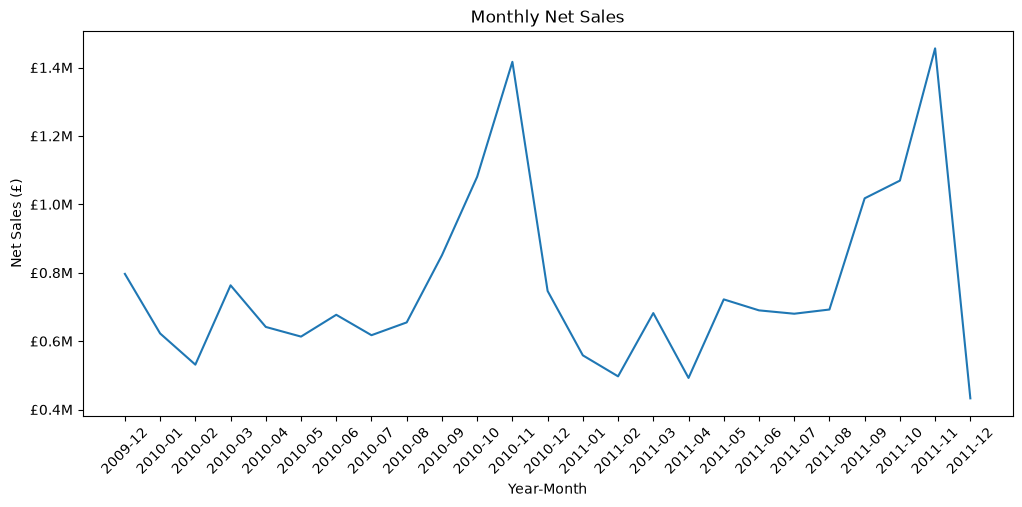

In [247]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales["Net Sales"]
)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)

plt.title("Monthly Net Sales")
plt.xlabel("Year-Month")
plt.ylabel("Net Sales (£)")

plt.show()

In [248]:
monthly_sales["Order Volume"]

Year-Month
2009-12    1682
2010-01    1105
2010-02    1201
2010-03    1681
2010-04    1462
2010-05    1500
2010-06    1645
2010-07    1529
2010-08    1425
2010-09    1839
2010-10    2301
2010-11    2747
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1360
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: Order Volume, dtype: int64

In [249]:
def thousands_formatter(x, pos):
    return f"{x:,.0f}"

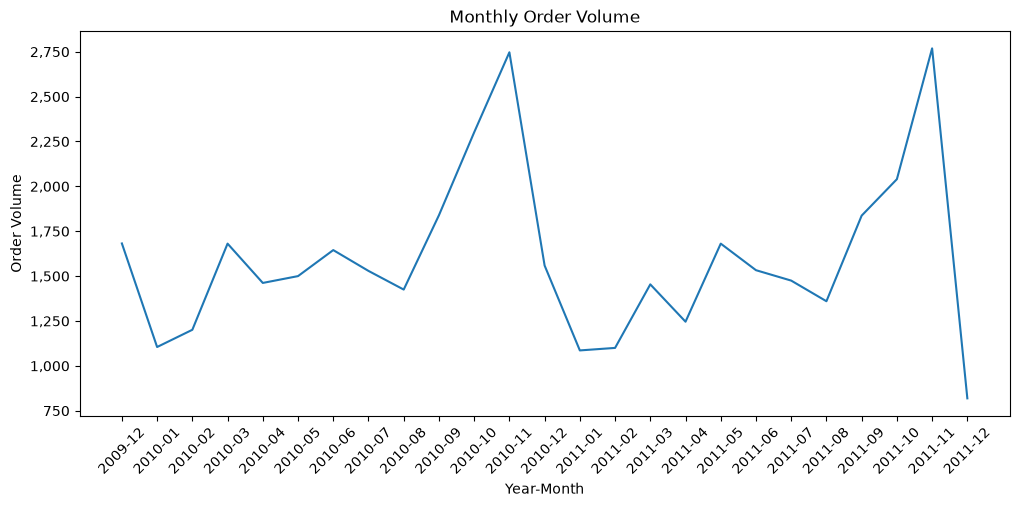

In [250]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales["Order Volume"]
)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(thousands_formatter)
)

plt.title("Monthly Order Volume")
plt.xlabel("Year-Month")
plt.ylabel("Order Volume")

plt.show()

In [251]:
monthly_sales["Net Units Sold"]

Year-Month
2009-12    415445
2010-01    386792
2010-02    374928
2010-03    521549
2010-04    360222
2010-05    379269
2010-06    391338
2010-07    331710
2010-08    465691
2010-09    488583
2010-10    608496
2010-11    707445
2010-12    342009
2011-01    307255
2011-02    280069
2011-03    371424
2011-04    294309
2011-05    389133
2011-06    381175
2011-07    393666
2011-08    408674
2011-09    562243
2011-10    598077
2011-11    738782
2011-12    230044
Freq: M, Name: Net Units Sold, dtype: int64

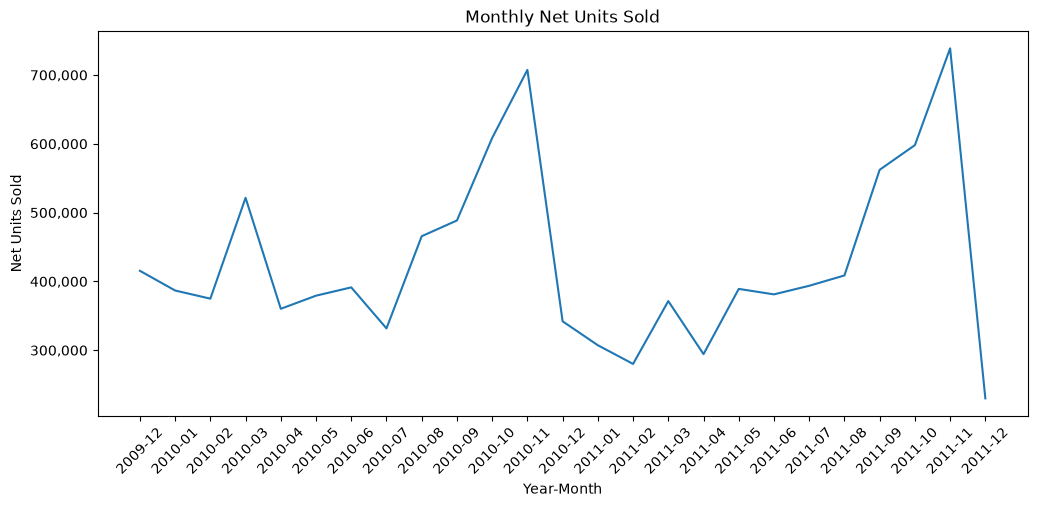

In [252]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales["Net Units Sold"]
)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(thousands_formatter)
)

plt.title("Monthly Net Units Sold")
plt.xlabel("Year-Month")
plt.ylabel("Net Units Sold")

plt.show()

#### Key Findings — Sales Performance Over Time

- **Net sales, order volume, and net units sold followed broadly similar patterns over time**, indicating that changes in revenue were generally accompanied by changes in purchasing activity and product volume.

- **Sales performance was generally weaker at the beginning of the year and strengthened toward the final months.** In both 2010 and 2011, performance accelerated particularly from August/September onward.

- **November was the strongest month in both complete years across all three metrics.** Net sales reached approximately £1.42M in November 2010 and £1.46M in November 2011, while order volume and net units sold also reached their respective annual peaks in November.

- **The repeated late-year increase suggests a seasonal sales pattern**, although the available data alone does not establish the underlying cause of this seasonality.

- **Net units sold showed greater fluctuations during some earlier periods**, particularly in March 2010. Further investigation showed that the March increase was primarily driven by higher gross unit sales rather than substantially lower cancellation volume.

- **December 2011 should not be directly compared with complete months**, as the dataset only contains transactions through December 9, 2011. The sharp decline at the end of the series therefore reflects a partial month rather than sufficient evidence of a deterioration in sales performance.

## Question 2 — Product Performance

**Which products generate the most revenue and sales volume?**

Product performance will be evaluated using two main metrics:

- **Net Sales:** sales value generated by each product after accounting for recorded cancellations.
- **Net Units Sold:** quantity sold for each product after accounting for cancelled quantities.

Products will be identified by `StockCode`, while the most recent valid description will be used as the representative product name.

In [253]:
retail_clean[["StockCode", "Description"]].head(10)

,StockCode,Description
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,79323P,PINK CHERRY LIGHTS
2,79323W,WHITE CHERRY LIGHTS
3,22041,"RECORD FRAME 7"" SINGLE SIZE"
4,21232,STRAWBERRY CERAMIC TRINKET BOX
5,22064,PINK DOUGHNUT TRINKET POT
6,21871,SAVE THE PLANET MUG
7,21523,FANCY FONT HOME SWEET HOME DOORMAT
8,22350,CAT BOWL
9,22349,"DOG BOWL , CHASING BALL DESIGN"


In [254]:
descriptions_per_stockcode = (
    retail_clean.groupby("StockCode")["Description"].nunique()
)

In [255]:
descriptions_per_stockcode[
    descriptions_per_stockcode > 1
]

StockCode
16011           2
16012           2
20615           2
20622           2
20652           2
               ..
90014A          2
90014B          2
90014C          2
ADJUST          2
BANK CHARGES    2
Name: Description, Length: 648, dtype: int64

In [256]:
retail_clean.loc[
    retail_clean["StockCode"] == "10080",
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description


In [257]:
retail_clean["StockCode"].head(10)

0     85048
1    79323P
2    79323W
3     22041
4     21232
5     22064
6     21871
7     21523
8     22350
9     22349
Name: StockCode, dtype: object

In [258]:
type(retail_clean["StockCode"].iloc[0])

int

In [259]:
retail_clean.loc[
    retail_clean["StockCode"] == 10080,
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description
6118,10080,GROOVY CACTUS INFLATABLE


In [260]:
retail_clean.loc[
    retail_clean["StockCode"] == 16011,
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description
10159,16011,ANIMAL STICKERS
114700,16011,ANIMAL STICKERS


In [261]:
retail_clean.loc[
    retail_clean["StockCode"] == 16011,
    "Description"
].drop_duplicates().map(repr)

10159     ' ANIMAL STICKERS'
114700     'ANIMAL STICKERS'
Name: Description, dtype: str

In [262]:
descriptions_per_stockcode_clean = (
    retail_clean["Description"]
    .str.strip()
    .groupby(retail_clean["StockCode"])
    .nunique()
)

In [263]:
(descriptions_per_stockcode_clean > 1).sum()

np.int64(623)

In [264]:
descriptions_per_stockcode_clean[
    descriptions_per_stockcode_clean > 1
].head(10)

StockCode
16012    2
20615    2
20622    2
20652    2
20658    2
20661    2
20665    2
20674    2
20675    2
20676    2
Name: Description, dtype: int64

In [265]:
sample_stockcodes = (
    descriptions_per_stockcode_clean[
        descriptions_per_stockcode_clean > 1
    ]
    .head(10)
    .index
)

In [266]:
retail_clean.loc[
    retail_clean["StockCode"].isin(sample_stockcodes),
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
3966,16012,FOOD/DRINK SPUNGE STICKERS
301744,16012,FOOD/DRINK SPONGE STICKERS
351940,20615,BLUE POLKADOT PASSPORT COVER
2385,20615,BLUE SPOTTY PASSPORT COVER
718831,20622,VIP PASSPORT COVER
589,20622,VIPPASSPORT COVER
339449,20652,BLUE POLKADOT LUGGAGE TAG
1758,20652,BLUE SPOTTY LUGGAGE TAG
2745,20658,RED SPOTTY LUGGAGE TAG
338894,20658,RED RETROSPOT LUGGAGE TAG


In [267]:
retail_clean.loc[
    retail_clean["StockCode"] == 20615,
    ["InvoiceDate", "StockCode", "Description"]
].sort_values("InvoiceDate")

,InvoiceDate,StockCode,Description
2385,2009-12-01 14:43:00,20615,BLUE SPOTTY PASSPORT COVER
2429,2009-12-01 14:44:00,20615,BLUE SPOTTY PASSPORT COVER
2575,2009-12-01 14:50:00,20615,BLUE SPOTTY PASSPORT COVER
5134,2009-12-02 14:36:00,20615,BLUE SPOTTY PASSPORT COVER
5410,2009-12-02 14:43:00,20615,BLUE SPOTTY PASSPORT COVER
...,...,...,...
975369,2011-11-28 15:54:00,20615,BLUE POLKADOT PASSPORT COVER
977939,2011-11-29 15:08:00,20615,BLUE POLKADOT PASSPORT COVER
982574,2011-11-30 15:33:00,20615,BLUE POLKADOT PASSPORT COVER
995156,2011-12-05 17:24:00,20615,BLUE POLKADOT PASSPORT COVER


In [268]:
retail_clean.loc[
    retail_clean["StockCode"] == 20615
].groupby("Description")["InvoiceDate"].agg(["min", "max"])

,min,max
Description,,
BLUE POLKADOT PASSPORT COVER,2010-10-01 13:30:00,2011-12-08 20:01:00
BLUE SPOTTY PASSPORT COVER,2009-12-01 14:43:00,2010-09-19 15:47:00


##### Product Identification

`StockCode` is used as the primary product identifier because some products appear under different descriptions over time while retaining the same stock code.

A review of these inconsistencies showed that they can result from description updates, spelling corrections, naming changes, or administrative entries. Therefore, grouping products directly by `Description` could incorrectly split the same product into multiple groups.

For reporting purposes, the most recent available description will be used as the representative product name for each `StockCode`.

In [269]:
description_counts = retail_clean["Description"].value_counts()

In [270]:
description_counts[
    description_counts.index.str.lower().isin(["check", "dotcom"])
]

Series([], Name: count, dtype: int64)

In [271]:
retail_clean.loc[
    retail_clean["Description"].str.lower().isin(["check", "dotcom"]),
    ["InvoiceDate", "Invoice", "StockCode", "Description", "Quantity", "Price"]
]

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price


In [272]:
(retail_clean["Price"] == 0).sum()

np.int64(0)

In [273]:
retail_clean.loc[
    retail_clean["Price"] == 0,
    "Description"
].value_counts()

Series([], Name: count, dtype: int64)

In [274]:
retail_clean.loc[
    retail_clean["Price"] == 0,
    "Quantity"
].sum()

np.int64(0)

In [275]:
retail_clean.loc[
    (retail_clean["Price"] == 0) &
    (retail_clean["Quantity"] == 12540),
    ["InvoiceDate", "Invoice", "StockCode", "Description", "Quantity", "Price"]
]

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price


In [276]:
retail_clean.loc[
    retail_clean["Invoice"] == 578841,
    ["InvoiceDate", "Invoice", "StockCode", "Description",
     "Quantity", "Price"]
]

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price


In [277]:
retail_clean.loc[
    retail_clean["StockCode"] == 84826,
    ["InvoiceDate", "Invoice", "Description", "Quantity", "Price"]
].sort_values("InvoiceDate")

,InvoiceDate,Invoice,Description,Quantity,Price
13113,2009-12-06 13:07:00,490488,ASSTD DESIGN 3D PAPER STICKERS,60,0.85
17521,2009-12-08 13:38:00,490926,ASSTD DESIGN 3D PAPER STICKERS,1,0.85
23053,2009-12-10 15:45:00,491340,ASSTD DESIGN 3D PAPER STICKERS,60,0.85
24540,2009-12-11 14:20:00,491622,ASSTD DESIGN 3D PAPER STICKERS,1,0.85
55617,2010-01-15 15:47:00,494625,ASSTD DESIGN 3D PAPER STICKERS,1,0.85
56713,2010-01-17 15:52:00,494673,ASSTD DESIGN 3D PAPER STICKERS,60,0.85
74231,2010-02-01 12:30:00,496431,ASSTD DESIGN 3D PAPER STICKERS,1,0.85
80193,2010-02-07 11:29:00,497200,ASSTD DESIGN 3D PAPER STICKERS,1,0.85
122038,2010-03-17 14:23:00,501541,ASSTD DESIGN 3D PAPER STICKERS,60,0.85
170725,2010-04-28 13:53:00,506253,ASSTD DESIGN 3D PAPER STICKERS,1,0.85


In [278]:
retail_clean["Price"].describe()

count    1.007912e+06
mean     4.063281e+00
std      4.921294e+01
min      1.000000e-03
25%      1.250000e+00
50%      2.100000e+00
75%      4.130000e+00
max      2.511109e+04
Name: Price, dtype: float64

In [279]:
(retail_clean["Price"] < 0).sum()

np.int64(0)

In [280]:
product_names = (
    retail_clean
    .sort_values("InvoiceDate")
    .drop_duplicates(subset="StockCode", keep="last")
    [["StockCode", "Description"]]
)

product_names.head(10)

,StockCode,Description
1257,84648,NEW BAROQUE WALL MIRROR
1688,21767,FRENCH STYLE WIRE DOOR CABINET
2077,30086C,ASSORTED FRUIT STRAWS
1774,20739,*USB Office Glitter Lamp
2410,72529w,WHITE ADVENT CANDLE
2454,79070b,ENGLISH ROSE SQUARE CAKE TINS
2570,85164b,BLACK BAROQUE CUCKOO CLOCK
2664,35004s,SET OF 3 SILVER FLYING DUCKS
3600,21838,DADDY MOUSE RED GINGHAM BOW TIE
3835,79065A,TEATIME ROUND CAKE TINS


In [281]:
product_names["StockCode"].duplicated().sum()

np.int64(0)

In [282]:
product_names["StockCode"].nunique()

4916

In [283]:
retail_clean.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Gross Sales', 'Year-Month'],
      dtype='str')

In [284]:
product_sales = (
    retail_clean
    .groupby("StockCode")["Gross Sales"]
    .sum()
    .reset_index()
)

product_sales.head(10)

,StockCode,Gross Sales
0,10002,6942.26
1,10080,129.29
2,10109,1.68
3,10120,142.74
4,10125,1715.78
5,10133,2373.26
6,10134,721.13
7,10135,4566.21
8,10138,111.22
9,11001,7408.65


In [285]:
cancelled_all = pd.concat(
    [cancelled_2009_2010, cancelled_2010_2011],
    ignore_index=True
)

In [286]:
cancelled_all.shape

(19104, 10)

In [287]:
product_cancellations = (
    cancelled_all
    .groupby("StockCode")["Cancellation Value"]
    .sum()
    .reset_index()
)

product_cancellations.head(10)


,StockCode,Cancellation Value
0,10002,-883.55
1,10120,-6.30
2,10133,-12.70
3,10134,-12.50
4,10135,-13.75
5,10138,-81.90
6,11001,-1093.39
7,15034,-116.06
8,15036,-644.03
9,15039,-22.95


In [288]:
product_performance = product_sales.merge(
    product_cancellations,
    on="StockCode",
    how="left"
)

product_performance.head(10)

,StockCode,Gross Sales,Cancellation Value
0,10002,6942.26,-883.55
1,10080,129.29,NaN
2,10109,1.68,NaN
3,10120,142.74,-6.30
4,10125,1715.78,NaN
5,10133,2373.26,-12.70
6,10134,721.13,-12.50
7,10135,4566.21,-13.75
8,10138,111.22,-81.90
9,11001,7408.65,-1093.39


In [289]:
product_performance["Cancellation Value"] = (
    product_performance["Cancellation Value"].fillna(0)
)

In [290]:
product_performance["Net Sales"] = (
    product_performance["Gross Sales"]
    + product_performance["Cancellation Value"]
)

In [291]:
product_performance.head(10)

,StockCode,Gross Sales,Cancellation Value,Net Sales
0,10002,6942.26,-883.55,6058.71
1,10080,129.29,0.00,129.29
2,10109,1.68,0.00,1.68
3,10120,142.74,-6.30,136.44
4,10125,1715.78,0.00,1715.78
5,10133,2373.26,-12.70,2360.56
6,10134,721.13,-12.50,708.63
7,10135,4566.21,-13.75,4552.46
8,10138,111.22,-81.90,29.32
9,11001,7408.65,-1093.39,6315.26


In [292]:
print("Product Net Sales:", product_performance["Net Sales"].sum())
print("Overall Net Sales:", net_sales)

Product Net Sales: 19011345.088
Overall Net Sales: 19003147.777999997


In [293]:
cancelled_only_codes = product_cancellations[
    ~product_cancellations["StockCode"].isin(product_sales["StockCode"])
]

cancelled_only_codes

,StockCode,Cancellation Value
99,20779,-14.79
209,21053,-4.25
330,21254,-11.80
372,21315,-17.00
392,21346,-5.95
614,21701,-20.28
660,21766,-33.90
797,22003,-67.50
2047,47567,-11.90
2321,85219,-4.95


In [294]:
cancelled_only_codes["Cancellation Value"].sum()

np.float64(-8197.31)

In [295]:
cancelled_all.loc[
    cancelled_all["StockCode"] == "CRUK",
    ["InvoiceDate", "Invoice", "StockCode", "Description",
     "Quantity", "Price", "Cancellation Value"]
]

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price,Cancellation Value
15555,2011-08-30 10:49:00,C564763,CRUK,CRUK Commission,-1,1.60,-1.60
15707,2011-09-02 15:45:00,C565382,CRUK,CRUK Commission,-1,13.01,-13.01
15858,2011-09-09 15:17:00,C566216,CRUK,CRUK Commission,-1,15.96,-15.96
15930,2011-09-13 12:32:00,C566565,CRUK,CRUK Commission,-1,52.24,-52.24
16123,2011-09-21 14:40:00,C567655,CRUK,CRUK Commission,-1,608.66,-608.66
16304,2011-09-26 15:28:00,C568345,CRUK,CRUK Commission,-1,447.56,-447.56
16481,2011-10-03 09:57:00,C569245,CRUK,CRUK Commission,-1,361.59,-361.59
16961,2011-10-10 17:12:00,C570487,CRUK,CRUK Commission,-1,411.92,-411.92
17260,2011-10-17 13:31:00,C571440,CRUK,CRUK Commission,-1,495.98,-495.98
17543,2011-10-24 17:07:00,C572551,CRUK,CRUK Commission,-1,425.14,-425.14


In [296]:
cancelled_all.loc[
    cancelled_all["StockCode"].isin(
        cancelled_only_codes.loc[
            cancelled_only_codes["StockCode"] != "CRUK",
            "StockCode"
        ]
    ),
    ["StockCode", "Description", "Quantity", "Price", "Cancellation Value"]
]

,StockCode,Description,Quantity,Price,Cancellation Value
40,21254,SET OF KITCHEN WALL STICKERS,-4,2.95,-11.80
222,79340W,WHITE ORCHID FLOWER LIGHTS,-1,7.95,-7.95
252,22003,VINTAGE BLUE VACUUM FLASK 0.5L,-10,6.75,-67.50
366,21701,SET 6 MINI SUSHI SET FRIDGE MAGNETS,-12,1.69,-20.28
468,21053,ZINC HEART HANGER WITH HOOKS,-1,4.25,-4.25
483,79340W,WHITE ORCHID FLOWER LIGHTS,-1,7.95,-7.95
588,35631B,BLUE GREEN CHRISTMAS HANGING BALL,-1,0.19,-0.19
652,79340P,PURPLE ORCHID FLOWER LIGHTS,-1,7.95,-7.95
691,35001C,HAND OPEN SHAPE CHROME,-3,3.39,-10.17
716,21766,VINTAGE WOOD ORGANISER,-2,16.95,-33.90


In [297]:
product_performance = product_performance.merge(
    product_names,
    on="StockCode",
    how="left"
)

In [298]:
product_performance.head(10)

,StockCode,Gross Sales,Cancellation Value,Net Sales,Description
0,10002,6942.26,-883.55,6058.71,INFLATABLE POLITICAL GLOBE
1,10080,129.29,0.00,129.29,GROOVY CACTUS INFLATABLE
2,10109,1.68,0.00,1.68,BENDY COLOUR PENCILS
3,10120,142.74,-6.30,136.44,DOGGY RUBBER
4,10125,1715.78,0.00,1715.78,MINI FUNKY DESIGN TAPES
5,10133,2373.26,-12.70,2360.56,COLOURING PENCILS BROWN TUBE
6,10134,721.13,-12.50,708.63,COLOURING PENCILS BROWN TUBE
7,10135,4566.21,-13.75,4552.46,COLOURING PENCILS BROWN TUBE
8,10138,111.22,-81.90,29.32,ASSORTED COLOUR JUMBO PEN
9,11001,7408.65,-1093.39,6315.26,ASSTD DESIGN RACING CAR PEN


In [299]:
product_units = (
    retail_clean
    .groupby("StockCode")["Quantity"]
    .sum()
    .reset_index(name="Gross Units Sold")
)

product_units.head(10)

,StockCode,Gross Units Sold
0,10002,8671
1,10080,315
2,10109,4
3,10120,664
4,10125,2103
5,10133,3837
6,10134,625
7,10135,4226
8,10138,261
9,11001,4829


In [300]:
product_cancelled_units = (
    cancelled_all
    .groupby("StockCode")["Quantity"]
    .sum()
    .reset_index(name="Cancelled Units")
)

product_cancelled_units.head(10)

,StockCode,Cancelled Units
0,10002,-1223
1,10120,-30
2,10133,-20
3,10134,-10
4,10135,-11
5,10138,-194
6,11001,-811
7,15034,-1448
8,15036,-929
9,15039,-27


In [301]:
product_units = product_units.merge(
    product_cancelled_units,
    on="StockCode",
    how="left"
)

In [302]:
product_units["Cancelled Units"] = (
    product_units["Cancelled Units"].fillna(0)
)

In [303]:
product_units["Net Units Sold"] = (
    product_units["Gross Units Sold"]
    + product_units["Cancelled Units"]
)

In [304]:
product_units.head(10)

,StockCode,Gross Units Sold,Cancelled Units,Net Units Sold
0,10002,8671,-1223.0,7448.0
1,10080,315,0.0,315.0
2,10109,4,0.0,4.0
3,10120,664,-30.0,634.0
4,10125,2103,0.0,2103.0
5,10133,3837,-20.0,3817.0
6,10134,625,-10.0,615.0
7,10135,4226,-11.0,4215.0
8,10138,261,-194.0,67.0
9,11001,4829,-811.0,4018.0


In [305]:
product_performance = product_performance.merge(
    product_units[["StockCode", "Net Units Sold"]],
    on="StockCode",
    how="left"
)

product_performance.head(10)

,StockCode,Gross Sales,Cancellation Value,Net Sales,Description,Net Units Sold
0,10002,6942.26,-883.55,6058.71,INFLATABLE POLITICAL GLOBE,7448.0
1,10080,129.29,0.00,129.29,GROOVY CACTUS INFLATABLE,315.0
2,10109,1.68,0.00,1.68,BENDY COLOUR PENCILS,4.0
3,10120,142.74,-6.30,136.44,DOGGY RUBBER,634.0
4,10125,1715.78,0.00,1715.78,MINI FUNKY DESIGN TAPES,2103.0
5,10133,2373.26,-12.70,2360.56,COLOURING PENCILS BROWN TUBE,3817.0
6,10134,721.13,-12.50,708.63,COLOURING PENCILS BROWN TUBE,615.0
7,10135,4566.21,-13.75,4552.46,COLOURING PENCILS BROWN TUBE,4215.0
8,10138,111.22,-81.90,29.32,ASSORTED COLOUR JUMBO PEN,67.0
9,11001,7408.65,-1093.39,6315.26,ASSTD DESIGN RACING CAR PEN,4018.0


In [306]:
print(
    "Product Net Units Sold:",
    product_performance["Net Units Sold"].sum()
)

print(
    "Overall Net Units Sold:",
    monthly_sales["Net Units Sold"].sum()
)

Product Net Units Sold: 10728398.0
Overall Net Units Sold: 10728328


In [307]:
cancelled_only_codes = cancelled_all[
    ~cancelled_all["StockCode"].isin(retail_clean["StockCode"])
]

cancelled_only_codes["Quantity"].sum()

np.int64(-70)

#### Top Products by Net Sales

Products are ranked by Net Sales to identify which items generated the highest revenue after accounting for recorded cancellations.

In [308]:
top_products_sales = (
    product_performance
    .sort_values("Net Sales", ascending=False)
    .head(10)
)

top_products_sales[
    ["StockCode", "Description", "Net Sales"]
]

,StockCode,Description,Net Sales
1513,22423,REGENCY CAKESTAND 3 TIER,314045.02
4900,DOT,DOTCOM POSTAGE,309844.10
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61
4441,85099B,JUMBO BAG RED RETROSPOT,178400.52
2817,47566,PARTY BUNTING,147079.73
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
1201,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
4903,POST,POSTAGE,110430.41
2917,79321,CHILLI LIGHTS,79905.13
1308,22197,POPCORN HOLDER,78903.62


In [309]:
retail_clean.loc[
    retail_clean["StockCode"].isin(["DOT", "POST"]),
    ["InvoiceDate", "Invoice", "StockCode", "Description", "Quantity", "Price"]
].head(30)

,InvoiceDate,Invoice,StockCode,Description,Quantity,Price
89,2009-12-01 09:28:00,489439,POST,POSTAGE,3,18.00
126,2009-12-01 09:55:00,489444,POST,POSTAGE,1,141.00
173,2009-12-01 10:10:00,489447,POST,POSTAGE,1,130.00
580,2009-12-01 11:50:00,489526,POST,POSTAGE,6,18.00
1158,2009-12-01 12:52:00,489557,POST,POSTAGE,4,18.00
2255,2009-12-01 14:28:00,489597,DOT,DOTCOM POSTAGE,1,647.19
2415,2009-12-01 14:43:00,489600,DOT,DOTCOM POSTAGE,1,55.96
2427,2009-12-01 14:44:00,489601,DOT,DOTCOM POSTAGE,1,68.39
2447,2009-12-01 14:45:00,489602,DOT,DOTCOM POSTAGE,1,59.35
2495,2009-12-01 14:46:00,489603,DOT,DOTCOM POSTAGE,1,42.39


In [310]:
product_performance.sort_values(
    "Net Sales",
    ascending=False
)[
    ["StockCode", "Description", "Net Sales"]
].head(30)

,StockCode,Description,Net Sales
1513,22423,REGENCY CAKESTAND 3 TIER,314045.02
4900,DOT,DOTCOM POSTAGE,309844.10
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61
4441,85099B,JUMBO BAG RED RETROSPOT,178400.52
2817,47566,PARTY BUNTING,147079.73
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
1201,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
4903,POST,POSTAGE,110430.41
2917,79321,CHILLI LIGHTS,79905.13
1308,22197,POPCORN HOLDER,78903.62


In [311]:
product_performance_clean = product_performance[
    ~product_performance["StockCode"].isin(["DOT", "POST"])
].copy()

In [312]:
product_performance_clean[
    ["StockCode", "Description", "Net Sales"]
].sort_values(
    "Net Sales",
    ascending=False
).head(10)

,StockCode,Description,Net Sales
1513,22423,REGENCY CAKESTAND 3 TIER,314045.02
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61
4441,85099B,JUMBO BAG RED RETROSPOT,178400.52
2817,47566,PARTY BUNTING,147079.73
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
1201,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
2917,79321,CHILLI LIGHTS,79905.13
1308,22197,POPCORN HOLDER,78903.62
1482,22386,JUMBO BAG PINK POLKADOT,75457.64
2979,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95


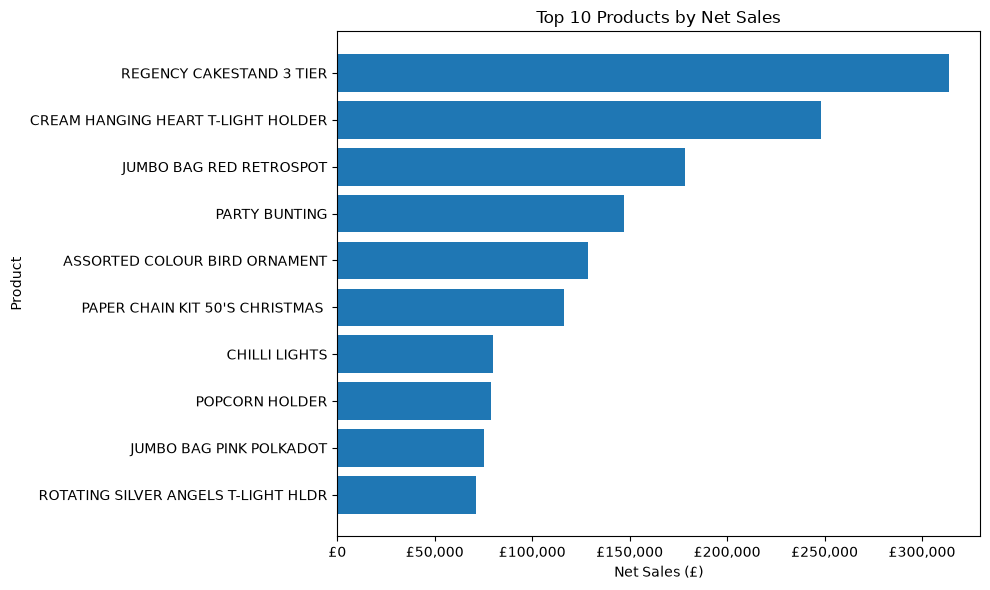

In [386]:
top_products_sales = (
    product_performance_clean
    .sort_values("Net Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_sales["Description"],
    top_products_sales["Net Sales"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Net Sales")
plt.xlabel("Net Sales (£)")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.savefig("../images/top_10_products_net_sales.png", dpi=300, bbox_inches="tight")
plt.show()

**Net Sales Analysis**

The revenue ranking shows a clear concentration among the leading products. `REGENCY CAKESTAND 3 TIER` generated the highest Net Sales at approximately £314K, followed by `CREAM HANGING HEART T-LIGHT HOLDER` at approximately £248K.

A noticeable gap appears after the two leading products, with `JUMBO BAG RED RETROSPOT` ranking third at approximately £178K. The remaining products in the Top 10 generated substantially lower Net Sales, indicating that a relatively small number of products account for particularly strong revenue performance.

#### Top Products by Net Units Sold

Product performance is also evaluated by Net Units Sold to identify the products with the highest sales volume after accounting for cancelled quantities.

In [314]:
top_products_units = (
    product_performance_clean
    .sort_values("Net Units Sold", ascending=False)
    .head(10)
)

top_products_units[
    ["StockCode", "Description", "Net Units Sold"]
]

,StockCode,Description,Net Units Sold
2963,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,104435.0
4441,85099B,JUMBO BAG RED RETROSPOT,95544.0
490,21212,PACK OF 72 RETROSPOT CAKE CASES,93774.0
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,90566.0
1308,22197,POPCORN HOLDER,87695.0
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,79571.0
50,17003,BROCADE RING PURSE,69629.0
1121,21977,PACK OF 60 PINK PAISLEY CAKE CASES,55842.0
3173,84991,60 TEATIME FAIRY CAKE CASES,53678.0
12,15036,ASSORTED COLOURS SILK FAN,43343.0


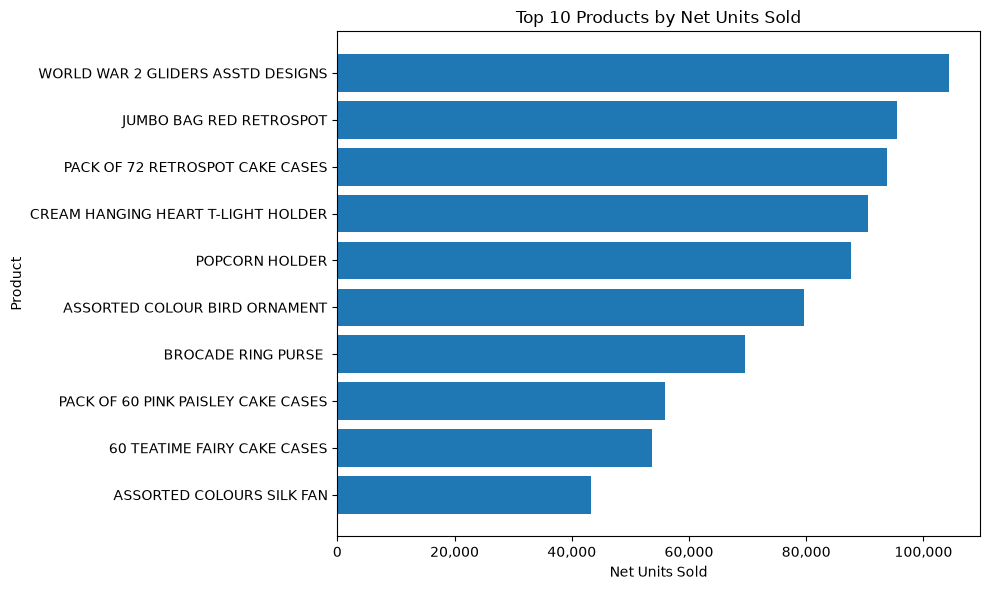

In [315]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_units["Description"],
    top_products_units["Net Units Sold"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Net Units Sold")
plt.xlabel("Net Units Sold")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

**Net Units Sold Analysis**

The sales-volume ranking differs from the Net Sales ranking. `WORLD WAR 2 GLIDERS ASSTD DESIGNS` recorded the highest sales volume, with approximately 104K net units sold, followed by `JUMBO BAG RED RETROSPOT` with approximately 96K units.

Several products, including `JUMBO BAG RED RETROSPOT`, `CREAM HANGING HEART T-LIGHT HOLDER`, `POPCORN HOLDER`, and `ASSORTED COLOUR BIRD ORNAMENT`, appear among the Top 10 in both Net Sales and Net Units Sold. However, other high-volume products do not rank among the highest revenue-generating products, indicating that sales volume alone does not determine product revenue performance.

In [316]:
products_in_both = top_products_sales[
    top_products_sales["StockCode"].isin(
        top_products_units["StockCode"]
    )
]

products_in_both[
    ["StockCode", "Description", "Net Sales", "Net Units Sold"]
]

,StockCode,Description,Net Sales,Net Units Sold
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61,90566.0
4441,85099B,JUMBO BAG RED RETROSPOT,178400.52,95544.0
3132,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,79571.0
1308,22197,POPCORN HOLDER,78903.62,87695.0


In [317]:
len(products_in_both)

4

#### Key Findings — Product Performance

- `REGENCY CAKESTAND 3 TIER` generated the highest Net Sales, approximately £314K.
- `WORLD WAR 2 GLIDERS ASSTD DESIGNS` recorded the highest sales volume, with approximately 104K net units sold.
- Four products appeared in both Top 10 rankings, representing a 40% overlap.
- The differences between the rankings demonstrate that high sales volume does not necessarily translate into high revenue.
- Postage-related codes (`DOT` and `POST`) were excluded from product rankings to focus on merchandise performance.

### Additional Analysis — Most Cancelled Products

This analysis identifies the products with the highest recorded cancellation values and examines their potential impact on business revenue.

Two perspectives will be considered:

- **Cancellation Value:** products with the largest monetary amounts cancelled.
- **Cancelled Units:** products with the highest quantities cancelled.

The analysis uses recorded cancellation transactions and excludes non-product charges from product rankings.

The objective is to identify products that may require further investigation, rather than assume that cancellations necessarily indicate product quality issues.

In [318]:
product_cancellations = (
    cancelled_all
    .groupby("StockCode")["Cancellation Value"]
    .sum()
    .reset_index()
)

product_cancellations.head()

,StockCode,Cancellation Value
0,10002,-883.55
1,10120,-6.30
2,10133,-12.70
3,10134,-12.50
4,10135,-13.75


In [319]:
top_cancelled_products_value = (
    product_cancellations[
        ~product_cancellations["StockCode"].isin(["DOT", "POST", "C2"])
    ]
    .sort_values("Cancellation Value", ascending=True)
    .head(10)
)

top_cancelled_products_value

,StockCode,Cancellation Value
2892,M,-422552.57
2886,AMAZONFEE,-241988.30
1986,23843,-168469.60
1734,23166,-77479.64
2887,BANK CHARGES,-36001.49
1142,22423,-16545.30
2890,D,-13277.52
2744,85123A,-9387.10
2889,CRUK,-7933.43
2073,71477,-7164.12


In [320]:
cancelled_all.loc[
    cancelled_all["StockCode"].isin(
        ["M", "AMAZONFEE", "23843", "23166",
         "BANK CHARGES", "D", "CRUK"]
    ),
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
8965,AMAZONFEE,AMAZON FEE
385,BANK CHARGES,Bank Charges
2407,BANK CHARGES,Bank Charges
15555,CRUK,CRUK Commission
36,D,Discount
109,M,Manual


In [321]:
retail_clean.loc[
    retail_clean["StockCode"].isin(["23843", "23166"]),
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description


In [322]:
print("retail_clean:", retail_clean["StockCode"].dtype)
print("cancelled_all:", cancelled_all["StockCode"].dtype)

retail_clean: object
cancelled_all: object


In [323]:
cancelled_all.loc[
    cancelled_all["StockCode"].astype(str).str.strip().isin(["23843", "23166"]),
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Cancellation Value"]
]

,Invoice,StockCode,Description,Quantity,Price,Cancellation Value
10882,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,-77183.60
13506,C554527,23166,MEDIUM CERAMIC TOP STORAGE JAR,-9,1.04,-9.36
14045,C557508,23166,MEDIUM CERAMIC TOP STORAGE JAR,-240,1.04,-249.60
14748,C560540,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,1.25,-1.25
15108,C562375,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,1.25,-15.00
15244,C562952,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,1.25,-1.25
16093,C567535,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,1.25,-1.25
16125,C567677,23166,MEDIUM CERAMIC TOP STORAGE JAR,-2,1.04,-2.08
17071,C570867,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,1.25,-15.00
17584,C572991,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,1.25,-1.25


In [324]:
top_cancelled_products_value = (
    product_cancellations[
        ~product_cancellations["StockCode"].isin(
            ["DOT", "POST", "C2", "M", "AMAZONFEE",
             "BANK CHARGES", "D", "CRUK"]
        )
    ]
    .sort_values("Cancellation Value", ascending=True)
    .head(10)
)

top_cancelled_products_value

,StockCode,Cancellation Value
1986,23843,-168469.60
1734,23166,-77479.64
1142,22423,-16545.30
2744,85123A,-9387.10
2073,71477,-7164.12
240,21108,-6614.37
2534,79323W,-6421.10
2895,S,-6127.96
707,21843,-5270.25
2558,84078A,-5187.65


In [325]:
cancelled_all.loc[
    cancelled_all["StockCode"] == "S",
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description
2401,S,SAMPLES


In [326]:
top_cancelled_products_value = (
    product_cancellations[
        ~product_cancellations["StockCode"].isin(
            ["DOT", "POST", "C2", "M", "AMAZONFEE",
             "BANK CHARGES", "D", "CRUK", "S"]
        )
    ]
    .sort_values("Cancellation Value", ascending=True)
    .head(10)
)

top_cancelled_products_value

,StockCode,Cancellation Value
1986,23843,-168469.60
1734,23166,-77479.64
1142,22423,-16545.30
2744,85123A,-9387.10
2073,71477,-7164.12
240,21108,-6614.37
2534,79323W,-6421.10
707,21843,-5270.25
2558,84078A,-5187.65
1694,23113,-4803.06


In [327]:
cancelled_all.loc[
    cancelled_all["StockCode"].isin(
        top_cancelled_products_value["StockCode"]
    ),
    ["StockCode", "Description"]
].drop_duplicates().sort_values(
    "StockCode",
    key=lambda column: column.astype(str)
)

,StockCode,Description
585,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR
111,21843,RETRO SPOT CAKE STAND
3354,21843,RED RETROSPOT CAKE STAND
3041,22423,REGENCY CAKESTAND 3 TIER
16086,23113,PANTRY CHOPPING BOARD
10882,23166,MEDIUM CERAMIC TOP STORAGE JAR
19097,23843,"PAPER CRAFT , LITTLE BIRDIE"
627,71477,COLOUR GLASS. STAR T-LIGHT HOLDER
18504,71477,COLOURED GLASS STAR T-LIGHT HOLDER
63,79323W,WHITE CHERRY LIGHTS


In [328]:
top_cancelled_products_value = top_cancelled_products_value.merge(
    cancelled_all[["StockCode", "Description"]]
    .dropna(subset=["Description"])
    .drop_duplicates(subset=["StockCode"]),
    on="StockCode",
    how="left"
)

top_cancelled_products_value

,StockCode,Cancellation Value,Description
0,23843,-168469.60,"PAPER CRAFT , LITTLE BIRDIE"
1,23166,-77479.64,MEDIUM CERAMIC TOP STORAGE JAR
2,22423,-16545.30,REGENCY CAKESTAND 3 TIER
3,85123A,-9387.10,WHITE HANGING HEART T-LIGHT HOLDER
4,71477,-7164.12,COLOUR GLASS. STAR T-LIGHT HOLDER
5,21108,-6614.37,FAIRY CAKE FLANNEL ASSORTED COLOUR
6,79323W,-6421.10,WHITE CHERRY LIGHTS
7,21843,-5270.25,RETRO SPOT CAKE STAND
8,84078A,-5187.65,SET/4 WHITE RETRO STORAGE CUBES
9,23113,-4803.06,PANTRY CHOPPING BOARD


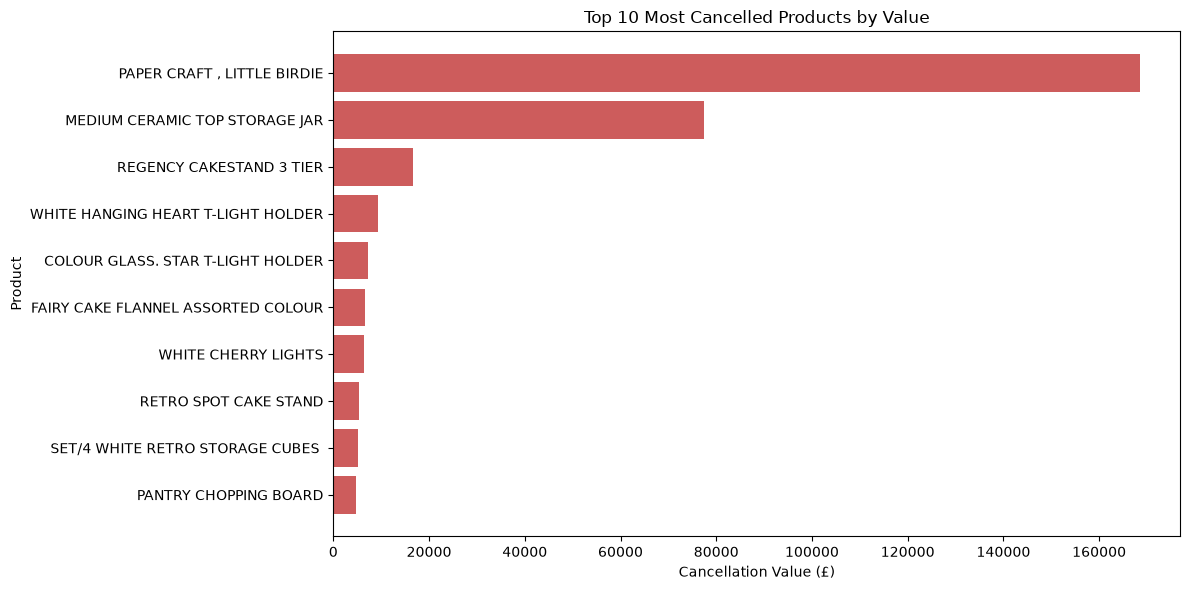

In [329]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_cancelled_products_value["Description"],
    -top_cancelled_products_value["Cancellation Value"],
    color="indianred"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Cancelled Products by Value")
plt.xlabel("Cancellation Value (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Key Findings — Product Cancellations

- **PAPER CRAFT, LITTLE BIRDIE** had the highest cancellation value (£168,469.60), followed by **MEDIUM CERAMIC TOP STORAGE JAR** (£77,479.64).
- Both products' cancellation totals were heavily influenced by single transactions involving unusually large quantities.
- Cancellation values were highly concentrated in these two products, while the remaining products had substantially lower totals.
- High cancellation values do not necessarily indicate frequent cancellations or customer dissatisfaction. The underlying reasons cannot be determined from the available transaction data.

**Business Insight:** Large individual cancellations can significantly affect product-level revenue. Businesses should investigate exceptional transactions separately from recurring cancellation patterns to distinguish isolated events from potential operational issues.

In [330]:
product_cancelled_units = (
    cancelled_all
    .groupby("StockCode")["Quantity"]
    .sum()
    .abs()
    .reset_index(name="Cancelled Units")
)

product_cancelled_units.head()

,StockCode,Cancelled Units
0,10002,1223
1,10120,30
2,10133,20
3,10134,10
4,10135,11


In [331]:
top_cancelled_products_units = (
    product_cancelled_units[
        ~product_cancelled_units["StockCode"].isin(
            ["DOT", "POST", "C2", "M", "AMAZONFEE",
             "BANK CHARGES", "D", "CRUK", "S"]
        )
    ]
    .sort_values("Cancelled Units", ascending=False)
    .head(10)
)

top_cancelled_products_units

,StockCode,Cancelled Units
1986,23843,80995
1734,23166,74494
2140,84347,9381
231,21088,7140
235,21096,7008
14,16047,5184
2286,85110,5040
2010,37340,4996
13,16046,4632
2762,85160A,4320


In [332]:
top_cancelled_products_units = top_cancelled_products_units.merge(
    cancelled_all[["StockCode", "Description"]]
    .dropna(subset=["Description"])
    .drop_duplicates(subset=["StockCode"]),
    on="StockCode",
    how="left"
)

top_cancelled_products_units

,StockCode,Cancelled Units,Description
0,23843,80995,"PAPER CRAFT , LITTLE BIRDIE"
1,23166,74494,MEDIUM CERAMIC TOP STORAGE JAR
2,84347,9381,ROTATING SILVER ANGELS T-LIGHT HLDR
3,21088,7140,SET/6 FRUIT SALAD PAPER CUPS
4,21096,7008,SET/6 FRUIT SALAD PAPER PLATES
5,16047,5184,POP ART PEN CASE & PENS
6,85110,5040,BLACK SILVER FLOWER T-LIGHT HOLDER
7,37340,4996,MULTICOLOUR SPRING FLOWER MUG
8,16046,4632,TEATIME PEN CASE & PENS
9,85160A,4320,WHITE BIRD GARDEN DESIGN MUG


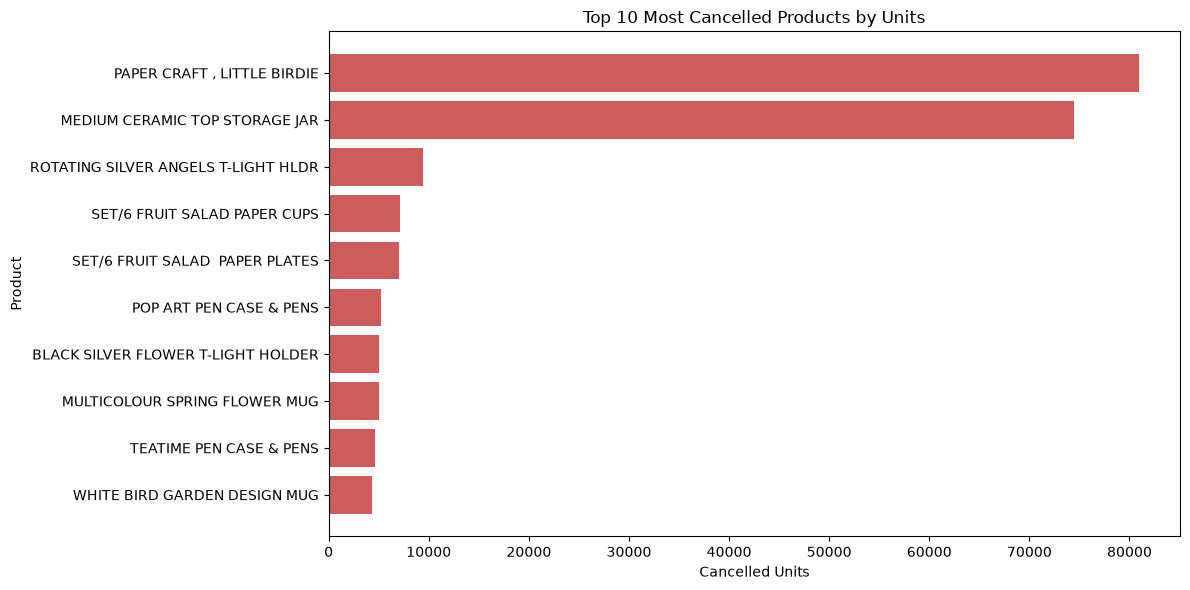

In [333]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_cancelled_products_units["Description"],
    top_cancelled_products_units["Cancelled Units"],
    color="indianred"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Cancelled Products by Units")
plt.xlabel("Cancelled Units")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Key Findings — Cancelled Units

- **PAPER CRAFT, LITTLE BIRDIE** recorded the highest number of cancelled units (80,995), followed by **MEDIUM CERAMIC TOP STORAGE JAR** (74,494).
- Both products also ranked first and second in cancellation value, indicating that they dominate the cancellation rankings in both monetary value and quantity.
- Their totals were heavily influenced by individual transactions involving exceptionally large quantities, rather than necessarily reflecting repeated cancellation activity.
- The third-ranked product, **ROTATING SILVER ANGELS T-LIGHT HLDR**, had 9,381 cancelled units, substantially fewer than the two leading products.

**Business Insight:** Cancellation volumes should be analyzed alongside transaction frequency and individual transaction sizes. Investigating unusually large cancellations separately can help prevent isolated events from being mistaken for recurring product performance issues.

### Additional Analysis — Sales vs. Cancellations

This analysis examines whether the products with the highest sales volumes are also among those with the highest cancellation volumes.

The objective is to identify overlaps between the Top 10 best-selling products by net units and the Top 10 most cancelled products by units.

However, high cancellation volumes do not necessarily indicate poor product performance, as popular products may naturally experience more cancellations. Therefore, cancellation volumes should also be evaluated relative to sales volumes.

The analysis will first identify products appearing in both rankings and then investigate their cancellation proportions, while considering the impact of unusually large transactions.

In [334]:
products_sold_and_cancelled = top_products_units[
    top_products_units["StockCode"].isin(
        top_cancelled_products_units["StockCode"]
    )
]

products_sold_and_cancelled

,StockCode,Gross Sales,Cancellation Value,Net Sales,Description,Net Units Sold


In [335]:
products_sold_and_cancelled_value = top_products_sales[
    top_products_sales["StockCode"].isin(
        top_cancelled_products_value["StockCode"]
    )
]

products_sold_and_cancelled_value

,StockCode,Gross Sales,Cancellation Value,Net Sales,Description,Net Units Sold
1513,22423,330590.32,-16545.3,314045.02,REGENCY CAKESTAND 3 TIER,25028.0
4456,85123A,257724.71,-9387.1,248337.61,CREAM HANGING HEART T-LIGHT HOLDER,90566.0


In [336]:
products_sold_and_cancelled_value["Cancellation Rate (%)"] = (
    -products_sold_and_cancelled_value["Cancellation Value"]
    / products_sold_and_cancelled_value["Gross Sales"]
    * 100
)

products_sold_and_cancelled_value[
    ["StockCode", "Description", "Gross Sales",
     "Cancellation Value", "Cancellation Rate (%)"]
]

,StockCode,Description,Gross Sales,Cancellation Value,Cancellation Rate (%)
1513,22423,REGENCY CAKESTAND 3 TIER,330590.32,-16545.3,5.004774
4456,85123A,CREAM HANGING HEART T-LIGHT HOLDER,257724.71,-9387.1,3.642297


#### Key Findings — Sales vs. Cancellations

- None of the Top 10 products by net units sold appeared among the Top 10 products by cancelled units.
- Two products appeared in both the Top 10 by net sales and the Top 10 by cancellation value: **REGENCY CAKESTAND 3 TIER** and **CREAM HANGING HEART T-LIGHT HOLDER**.
- Cancellation values represented approximately **5.00%** and **3.64%** of their respective gross sales.
- These results show that products with strong sales performance can also have substantial cancellation values. However, absolute cancellation amounts should be interpreted relative to sales volume.

**Business Insight:** Comparing cancellation values with gross sales provides more context than cancellation rankings alone. This approach can help identify products that warrant further investigation without automatically treating high cancellation values as evidence of poor performance.

## Question 3 — Customer Analysis

**Who were the highest-value customers based on total spending, purchase frequency, and units purchased?**

Customer performance will be evaluated using three main metrics:

- **Net Spending:** total customer spending after accounting for recorded cancellations.
- **Purchase Frequency:** number of distinct purchase invoices associated with each customer.
- **Net Units Purchased:** total quantity purchased after accounting for cancelled units.

The analysis will use `Customer ID` to identify customers and will reuse the cleaned sales and cancellation datasets from previous questions.

In [337]:
print("Sales transactions:")
print(retail_clean["Customer ID"].isna().sum())

print("Cancellation transactions:")
print(cancelled_all["Customer ID"].isna().sum())

Sales transactions:
228487
Cancellation transactions:
714


In [338]:
customer_sales = retail_clean.dropna(
    subset=["Customer ID"]
).copy()

customer_cancellations = cancelled_all.dropna(
    subset=["Customer ID"]
).copy()

In [339]:
print("Customer sales:", len(customer_sales))
print("Customer cancellations:", len(customer_cancellations))

Customer sales: 779425
Customer cancellations: 18390


In [340]:
customer_spending = (
    customer_sales
    .groupby("Customer ID")["Gross Sales"]
    .sum()
    .reset_index()
)

In [341]:
customer_spending.head()

,Customer ID,Gross Sales
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


In [342]:
customer_cancelled_spending = (
    customer_cancellations
    .groupby("Customer ID")["Cancellation Value"]
    .sum()
    .reset_index()
)

In [343]:
customer_cancelled_spending.head()

,Customer ID,Cancellation Value
0,12346.0,-77608.20
1,12349.0,-24.15
2,12352.0,-960.63
3,12359.0,-221.05
4,12360.0,-40.00


In [344]:
customer_spending = customer_spending.merge(
    customer_cancelled_spending,
    on="Customer ID",
    how="left"
)

In [345]:
customer_spending["Cancellation Value"] = (
    customer_spending["Cancellation Value"].fillna(0)
)

customer_spending["Net Spending"] = (
    customer_spending["Gross Sales"]
    + customer_spending["Cancellation Value"]
)

In [346]:
customer_spending.head()

,Customer ID,Gross Sales,Cancellation Value,Net Spending
0,12346.0,77556.46,-77608.20,-51.74
1,12347.0,4921.53,0.00,4921.53
2,12348.0,2019.40,0.00,2019.40
3,12349.0,4428.69,-24.15,4404.54
4,12350.0,334.40,0.00,334.40


In [347]:
top_customers_spending = (
    customer_spending
    .sort_values("Net Spending", ascending=False)
    .head(10)
)

top_customers_spending[
    ["Customer ID", "Net Spending"]
]

,Customer ID,Net Spending
5692,18102.0,570380.61
2277,14646.0,523342.07
1789,14156.0,296063.44
2538,14911.0,265757.91
5050,17450.0,231390.55
1331,13694.0,190020.84
5109,17511.0,168491.62
68,12415.0,143269.29
4295,16684.0,141502.25
2685,15061.0,124961.98


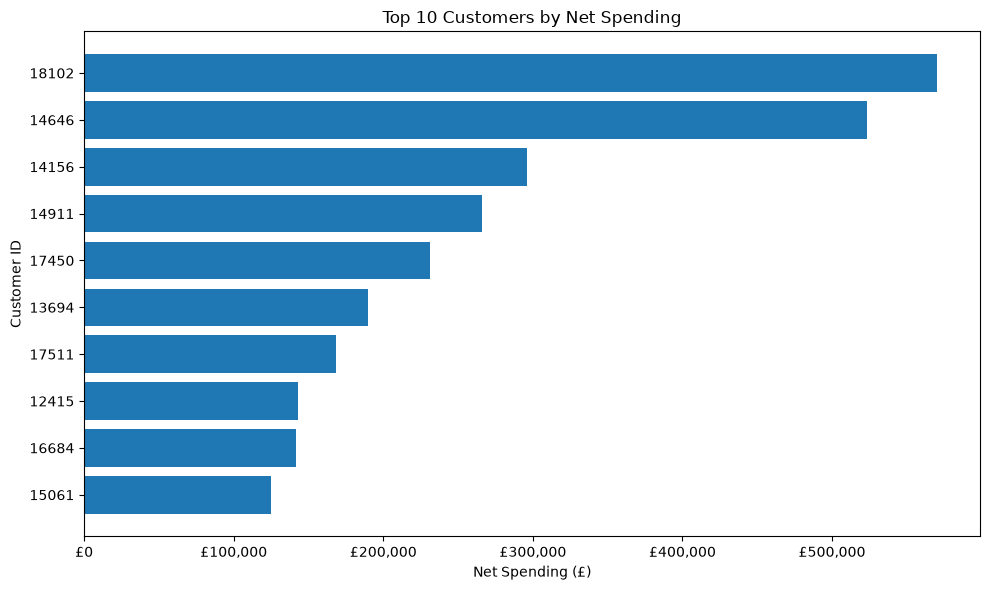

In [348]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_spending["Customer ID"].astype(int).astype(str),
    top_customers_spending["Net Spending"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Net Spending")
plt.xlabel("Net Spending (£)")
plt.ylabel("Customer ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

**Net Spending Analysis**

Customer `18102` recorded the highest Net Spending, approximately £570K, followed by customer `14646` at approximately £523K.

A substantial gap separates the two leading customers from the remaining Top 10, with customer `14156` ranking third at approximately £296K.

These results suggest that a small group of customers generates particularly high spending, highlighting the importance of identifying and retaining high-value customers.

In [349]:
customer_frequency = (
    customer_sales
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="Purchase Frequency")
)

In [350]:
customer_frequency.head()

,Customer ID,Purchase Frequency
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


In [351]:
top_customers_frequency = (
    customer_frequency
    .sort_values("Purchase Frequency", ascending=False)
    .head(10)
)

top_customers_frequency

,Customer ID,Purchase Frequency
2538,14911.0,398
400,12748.0,336
5433,17841.0,211
2935,15311.0,208
739,13089.0,203
2237,14606.0,192
1789,14156.0,156
5442,17850.0,155
2277,14646.0,151
5692,18102.0,145


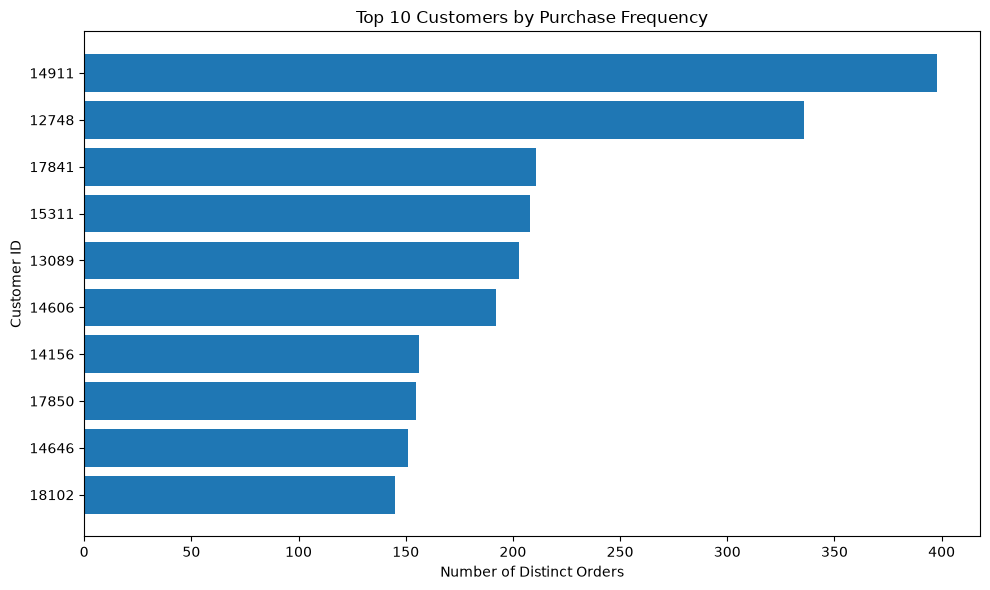

In [352]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_frequency["Customer ID"].astype(int).astype(str),
    top_customers_frequency["Purchase Frequency"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Number of Distinct Orders")
plt.ylabel("Customer ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

**Purchase Frequency Analysis**

Customer `14911` recorded the highest purchase frequency, with 398 distinct orders, followed by customer `12748` with 336 orders.

Customers `18102` and `14646`, who ranked first and second in Net Spending, also appeared among the Top 10 customers by purchase frequency.

However, neither led the purchase frequency ranking, indicating that the customers who spend the most are not necessarily those who place the most orders.

In [353]:
customer_units = (
    customer_sales
    .groupby("Customer ID")["Quantity"]
    .sum()
    .reset_index(name="Gross Units Purchased")
)

customer_units.head()

,Customer ID,Gross Units Purchased
0,12346.0,74285
1,12347.0,2967
2,12348.0,2714
3,12349.0,1624
4,12350.0,197


In [354]:
customer_cancelled_units = (
    customer_cancellations
    .groupby("Customer ID")["Quantity"]
    .sum()
    .reset_index(name="Cancelled Units")
)

customer_cancelled_units.head()

,Customer ID,Cancelled Units
0,12346.0,-74232
1,12349.0,-5
2,12352.0,-66
3,12359.0,-226
4,12360.0,-1


In [355]:
customer_units = customer_units.merge(
    customer_cancelled_units,
    on="Customer ID",
    how="left"
)

In [356]:
customer_units["Cancelled Units"] = (
    customer_units["Cancelled Units"].fillna(0)
)

customer_units["Net Units Purchased"] = (
    customer_units["Gross Units Purchased"]
    + customer_units["Cancelled Units"]
)

In [357]:
customer_units.head()

,Customer ID,Gross Units Purchased,Cancelled Units,Net Units Purchased
0,12346.0,74285,-74232.0,53.0
1,12347.0,2967,0.0,2967.0
2,12348.0,2714,0.0,2714.0
3,12349.0,1624,-5.0,1619.0
4,12350.0,197,0.0,197.0


In [358]:
top_customers_units = (
    customer_units
    .sort_values("Net Units Purchased", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_customers_units[
    ["Customer ID", "Net Units Purchased"]
]

,Customer ID,Net Units Purchased
0,14646.0,364580.0
1,13902.0,218090.0
2,13694.0,184534.0
3,18102.0,180415.0
4,14156.0,162245.0
5,14911.0,141500.0
6,17511.0,115449.0
7,16684.0,101095.0
8,14298.0,99854.0
9,12415.0,91019.0


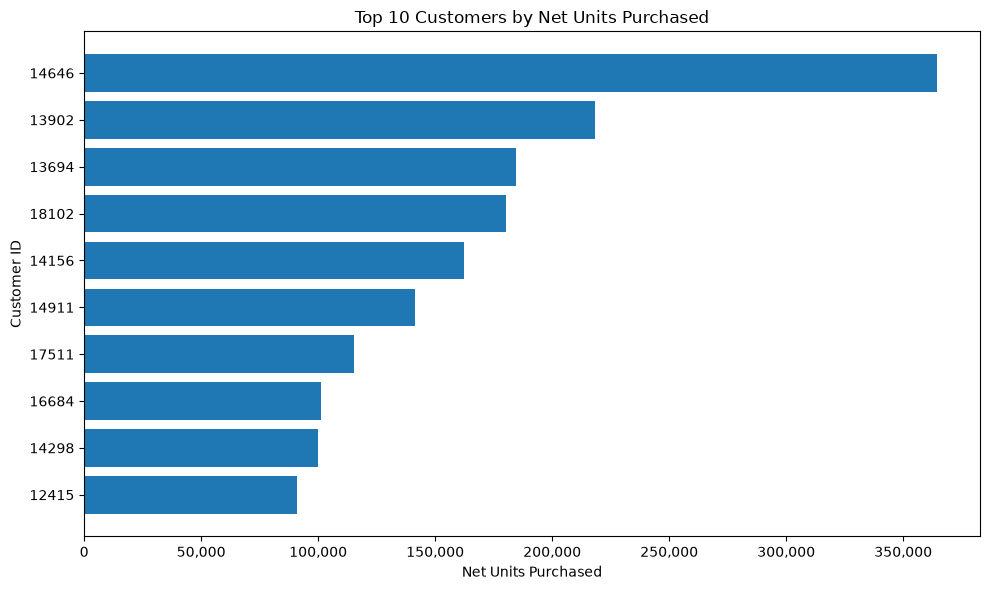

In [359]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers_units["Customer ID"].astype(int).astype(str),
    top_customers_units["Net Units Purchased"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Net Units Purchased")
plt.xlabel("Net Units Purchased")
plt.ylabel("Customer ID")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

**Net Units Purchased Analysis**

Customer `14646` recorded the highest Net Units Purchased, with approximately 365K units, followed by customer `13902` with approximately 218K units.

Customer `18102`, who ranked first in Net Spending, ranked fourth in Net Units Purchased, with approximately 180K units.

These results demonstrate that customers generating the highest revenue are not necessarily those purchasing the largest quantities of products.

In [360]:
customers_in_all_three = top_customers_spending[
    top_customers_spending["Customer ID"].isin(
        top_customers_frequency["Customer ID"]
    )
    &
    top_customers_spending["Customer ID"].isin(
        top_customers_units["Customer ID"]
    )
]

customers_in_all_three = (
    customers_in_all_three
    .merge(customer_frequency, on="Customer ID", how="left")
    .merge(
        customer_units[["Customer ID", "Net Units Purchased"]],
        on="Customer ID",
        how="left"
    )
)
customers_in_all_three[
    [
        "Customer ID",
        "Net Spending",
        "Purchase Frequency",
        "Net Units Purchased"
    ]
]

,Customer ID,Net Spending,Purchase Frequency,Net Units Purchased
0,18102.0,570380.61,145,180415.0
1,14646.0,523342.07,151,364580.0
2,14156.0,296063.44,156,162245.0
3,14911.0,265757.91,398,141500.0


In [361]:
len(customers_in_all_three) / len(top_customers_spending) * 100

40.0

#### Key Findings — Customer Analysis

- Customer `18102` generated the highest Net Spending, approximately £570K.
- Customer `14911` recorded the highest Purchase Frequency, with 398 distinct orders.
- Customer `14646` purchased the highest number of net units, approximately 365K.
- Four customers (`18102`, `14646`, `14156`, and `14911`) appeared in all three Top 10 rankings, representing a 40% overlap.
- The rankings demonstrate that high spending, frequent purchasing, and high purchase volume are related but distinct dimensions of customer value.

## Question 4 — Product Preferences of High-Value Customers

**Which products were most frequently purchased by the highest-value customers?**

This analysis examines the purchasing preferences of the Top 10 customers ranked by Net Spending.

Product popularity will be evaluated primarily using:

- **Purchase Frequency by Product:** number of distinct purchase invoices containing each product.
- **Net Units Purchased by Product:** total units purchased after accounting for recorded cancellations.

Products will be identified using `StockCode`, with representative descriptions used for readability. Postage-related codes (`DOT` and `POST`) will be excluded from merchandise rankings.

In [362]:
high_value_customer_sales = customer_sales[
    customer_sales["Customer ID"].isin(
        top_customers_spending["Customer ID"]
    )
].copy()

high_value_customer_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Gross Sales,Year-Month
54,489438,21329,DINOSAURS WRITING SET,28,2009-12-01 09:24:00,0.98,18102.0,United Kingdom,27.44,2009-12
55,489438,21252,SET OF MEADOW FLOWER STICKERS,30,2009-12-01 09:24:00,1.69,18102.0,United Kingdom,50.70,2009-12
56,489438,21100,CHARLIE AND LOLA CHARLOTTE BAG,30,2009-12-01 09:24:00,1.15,18102.0,United Kingdom,34.50,2009-12
57,489438,21033,JUMBO BAG CHARLIE AND LOLA TOYS,30,2009-12-01 09:24:00,2.00,18102.0,United Kingdom,60.00,2009-12
58,489438,20711,JUMBO BAG TOYS,60,2009-12-01 09:24:00,1.30,18102.0,United Kingdom,78.00,2009-12


In [363]:
print("Sales transaction rows:", len(high_value_customer_sales))

print(
    "Unique customers:",
    high_value_customer_sales["Customer ID"].nunique()
)

Sales transaction rows: 26353
Unique customers: 10


In [364]:
high_value_product_frequency = (
    high_value_customer_sales
    .groupby("StockCode")["Invoice"]
    .nunique()
    .reset_index(name="Purchase Frequency")
)

high_value_product_frequency.head()

,StockCode,Purchase Frequency
0,10002,6
1,10125,2
2,10133,4
3,10134,1
4,10135,4


In [365]:
top_high_value_products = (
    high_value_product_frequency[
        ~high_value_product_frequency["StockCode"].isin(["DOT", "POST"])
    ]
    .sort_values("Purchase Frequency", ascending=False)
    .head(10)
)

top_high_value_products

,StockCode,Purchase Frequency
1235,22423,199
3310,C2,178
352,21212,151
3158,85123A,134
3153,85099B,111
1425,22629,96
2541,84991,89
1489,22699,86
780,21843,85
64,20685,84


In [366]:
top_high_value_products = (
    high_value_product_frequency[
        ~high_value_product_frequency["StockCode"].isin(
            ["DOT", "POST", "C2"]
        )
    ]
    .sort_values("Purchase Frequency", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_high_value_products

,StockCode,Purchase Frequency
0,22423,199
1,21212,151
2,85123A,134
3,85099B,111
4,22629,96
5,84991,89
6,22699,86
7,21843,85
8,22197,84
9,20685,84


In [367]:
top_high_value_products = top_high_value_products.merge(
    product_performance[["StockCode", "Description"]],
    on="StockCode",
    how="left"
)

top_high_value_products[
    ["StockCode", "Description", "Purchase Frequency"]
]

,StockCode,Description,Purchase Frequency
0,22423,REGENCY CAKESTAND 3 TIER,199
1,21212,PACK OF 72 RETROSPOT CAKE CASES,151
2,85123A,CREAM HANGING HEART T-LIGHT HOLDER,134
3,85099B,JUMBO BAG RED RETROSPOT,111
4,22629,SPACEBOY LUNCH BOX,96
5,84991,60 TEATIME FAIRY CAKE CASES,89
6,22699,ROSES REGENCY TEACUP AND SAUCER,86
7,21843,RED RETROSPOT CAKE STAND,85
8,22197,POPCORN HOLDER,84
9,20685,DOORMAT RED RETROSPOT,84


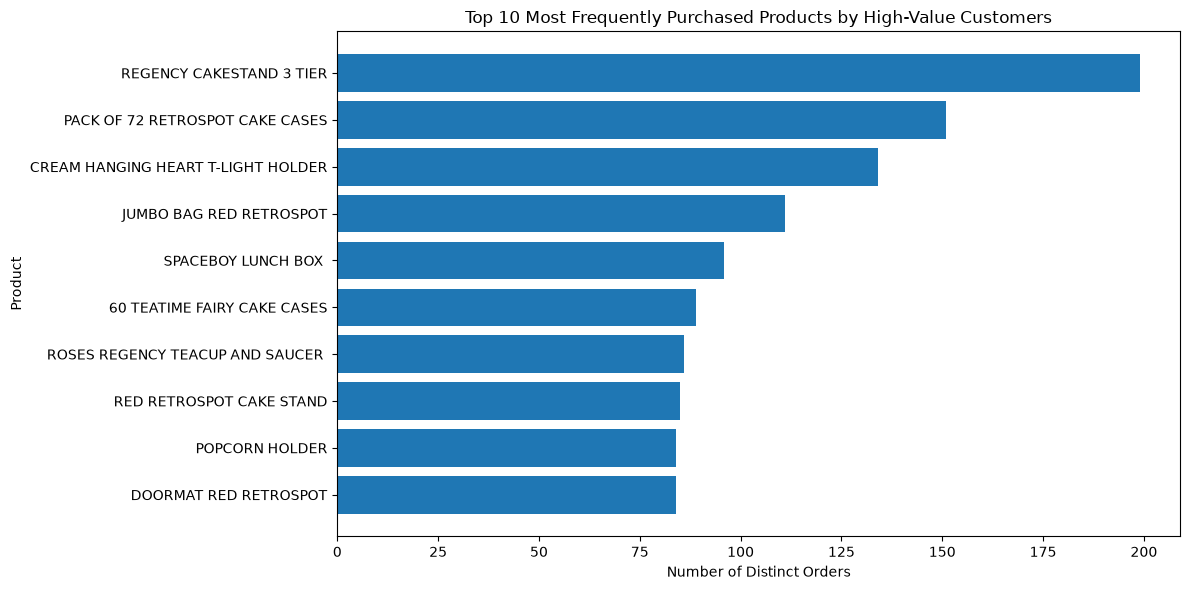

In [368]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_high_value_products["Description"],
    top_high_value_products["Purchase Frequency"]
)

plt.xlabel("Number of Distinct Orders")
plt.ylabel("Product")
plt.title("Top 10 Most Frequently Purchased Products by High-Value Customers")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Product Purchase Frequency Analysis**

The `REGENCY CAKESTAND 3 TIER` (StockCode `22423`) was the most frequently purchased product among the Top 10 high-value customers, appearing in 199 distinct orders.

The `PACK OF 72 RETROSPOT CAKE CASES` ranked second with 151 orders, followed by the `CREAM HANGING HEART T-LIGHT HOLDER` with 134 orders.

The ranking includes several cake-related, decorative, and household products, suggesting recurring demand for these product categories among high-value customers.

These results measure how frequently products appeared in distinct orders, rather than the total number of units purchased.

In [369]:
high_value_customer_cancellations = customer_cancellations[
    customer_cancellations["Customer ID"].isin(
        top_customers_spending["Customer ID"]
    )
].copy()

high_value_customer_cancellations.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation Value,Year-Month
250,C490721,21232,STRAWBERRY CERAMIC TRINKET BOX,-1,2009-12-07 15:45:00,1.25,14156.0,EIRE,-1.25,2009-12
251,C490721,84782C,GREEN 3 TIER GLASS PLATE STAND,-1,2009-12-07 15:45:00,12.75,14156.0,EIRE,-12.75,2009-12
338,C490934,20914,SET/5 RED SPOTTY LID GLASS BOWLS,-1,2009-12-08 13:49:00,2.55,14156.0,EIRE,-2.55,2009-12
468,C490997,21053,ZINC HEART HANGER WITH HOOKS,-1,2009-12-08 17:24:00,4.25,14911.0,EIRE,-4.25,2009-12
469,C490997,21652,GLASS ETCHED T-LIGHT HOLDER MEDIUM,-6,2009-12-08 17:24:00,1.95,14911.0,EIRE,-11.70,2009-12


In [370]:
high_value_product_units = (
    high_value_customer_sales
    .groupby("StockCode")["Quantity"]
    .sum()
    .reset_index(name="Gross Units Purchased")
)

high_value_product_units.head()

,StockCode,Gross Units Purchased
0,10002,260
1,10125,80
2,10133,200
3,10134,200
4,10135,180


In [371]:
high_value_cancelled_units = (
    high_value_customer_cancellations
    .groupby("StockCode")["Quantity"]
    .sum()
    .reset_index(name="Cancelled Units")
)

high_value_cancelled_units.head()

,StockCode,Cancelled Units
0,10138,-1
1,20674,-1
2,20675,-1
3,20676,-1
4,20677,-1


In [372]:
high_value_product_units = high_value_product_units.merge(
    high_value_cancelled_units,
    on="StockCode",
    how="left"
)

high_value_product_units["Cancelled Units"] = (
    high_value_product_units["Cancelled Units"].fillna(0)
)

high_value_product_units["Net Units Purchased"] = (
    high_value_product_units["Gross Units Purchased"]
    + high_value_product_units["Cancelled Units"]
)

high_value_product_units.head()

,StockCode,Gross Units Purchased,Cancelled Units,Net Units Purchased
0,10002,260,0.0,260.0
1,10125,80,0.0,80.0
2,10133,200,0.0,200.0
3,10134,200,0.0,200.0
4,10135,180,0.0,180.0


In [373]:
top_high_value_units = (
    high_value_product_units[
        ~high_value_product_units["StockCode"].isin(
            ["DOT", "POST", "C2"]
        )
    ]
    .sort_values("Net Units Purchased", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_high_value_units

,StockCode,Gross Units Purchased,Cancelled Units,Net Units Purchased
0,21212,20376,0.0,20376.0
1,85123A,13810,-478.0,13332.0
2,85099B,12292,-105.0,12187.0
3,21977,11100,-24.0,11076.0
4,22629,10444,0.0,10444.0
5,22189,9680,0.0,9680.0
6,22630,9344,-192.0,9152.0
7,22188,8254,0.0,8254.0
8,22492,8208,-36.0,8172.0
9,84991,8124,0.0,8124.0


In [374]:
top_high_value_units = top_high_value_units.merge(
    product_performance[["StockCode", "Description"]],
    on="StockCode",
    how="left"
)

top_high_value_units[
    ["StockCode", "Description", "Net Units Purchased"]
]

,StockCode,Description,Net Units Purchased
0,21212,PACK OF 72 RETROSPOT CAKE CASES,20376.0
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,13332.0
2,85099B,JUMBO BAG RED RETROSPOT,12187.0
3,21977,PACK OF 60 PINK PAISLEY CAKE CASES,11076.0
4,22629,SPACEBOY LUNCH BOX,10444.0
5,22189,CREAM HEART CARD HOLDER,9680.0
6,22630,DOLLY GIRL LUNCH BOX,9152.0
7,22188,BLACK HEART CARD HOLDER,8254.0
8,22492,MINI PAINT SET VINTAGE,8172.0
9,84991,60 TEATIME FAIRY CAKE CASES,8124.0


In [375]:
high_value_products_in_both = top_high_value_products[
    top_high_value_products["StockCode"].isin(
        top_high_value_units["StockCode"]
    )
]

high_value_products_in_both[
    ["StockCode", "Description", "Purchase Frequency"]
]

,StockCode,Description,Purchase Frequency
1,21212,PACK OF 72 RETROSPOT CAKE CASES,151
2,85123A,CREAM HANGING HEART T-LIGHT HOLDER,134
3,85099B,JUMBO BAG RED RETROSPOT,111
4,22629,SPACEBOY LUNCH BOX,96
5,84991,60 TEATIME FAIRY CAKE CASES,89


In [376]:
high_value_products_in_both = high_value_products_in_both.merge(
    top_high_value_units[["StockCode", "Net Units Purchased"]],
    on="StockCode",
    how="left"
)

high_value_products_in_both[
    ["StockCode", "Description", "Purchase Frequency", "Net Units Purchased"]
]

,StockCode,Description,Purchase Frequency,Net Units Purchased
0,21212,PACK OF 72 RETROSPOT CAKE CASES,151,20376.0
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,134,13332.0
2,85099B,JUMBO BAG RED RETROSPOT,111,12187.0
3,22629,SPACEBOY LUNCH BOX,96,10444.0
4,84991,60 TEATIME FAIRY CAKE CASES,89,8124.0


#### Key Findings — Product Preferences of High-Value Customers

- `REGENCY CAKESTAND 3 TIER` (`22423`) was the most frequently purchased product among the Top 10 customers by Net Spending, appearing in **199 distinct orders**.
- `PACK OF 72 RETROSPOT CAKE CASES` (`21212`) recorded the highest Net Units Purchased, with **20,376 units**, and ranked second in purchase frequency with **151 orders**.
- Five products appeared in both Top 10 rankings, representing a **50% overlap**.
- The shared products included cake cases, decorative household items, shopping bags, and lunch boxes.
- Purchase frequency and net units purchased reveal different aspects of product demand: products ordered more frequently are not necessarily those purchased in the largest quantities.

**Business Insight**

These findings help identify products with recurring demand among high-value customers. Such products may be useful for targeted marketing, inventory planning, and customer retention strategies.

## Question 5 — Sales Concentration & Product Revenue Contribution

**To what extent were sales concentrated among the highest-value customers, and how much did these customers contribute to the performance of the best-selling products?**

This analysis examines the concentration of revenue among the Top 10 customers ranked by Net Spending and evaluates their contribution to the best-selling products identified in Question 2.

The analysis focuses on two metrics:

- **Customer Revenue Concentration:** percentage of total Net Sales generated by the Top 10 highest-value customers.
- **Top Product Revenue Contribution:** percentage of each best-selling product's Net Sales attributable to these customers.

Net Sales accounts for recorded cancellations. Transactions without a `Customer ID` remain included in overall business revenue but cannot be attributed to individual customers.

In [377]:
top_10_net_spending = top_customers_spending["Net Spending"].sum()

print(f"Top 10 Customers Net Spending: £{top_10_net_spending:,.2f}")

Top 10 Customers Net Spending: £2,655,180.56


In [378]:
total_net_sales = (
    retail_clean["Gross Sales"].sum()
    + cancelled_all["Cancellation Value"].sum()
)

print(f"Total Net Sales: £{total_net_sales:,.2f}")

Total Net Sales: £19,003,147.78


In [379]:
top_10_revenue_share = (
    top_10_net_spending / total_net_sales
) * 100

print(f"Top 10 Customers Revenue Share: {top_10_revenue_share:.2f}%")

Top 10 Customers Revenue Share: 13.97%


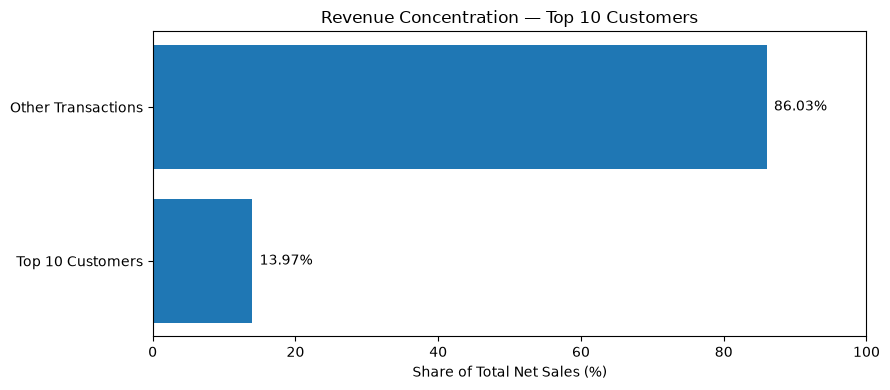

In [388]:
other_revenue_share = 100 - top_10_revenue_share

plt.figure(figsize=(9, 4))

plt.barh(
    ["Top 10 Customers", "Other Transactions"],
    [top_10_revenue_share, other_revenue_share]
)

plt.text(
    top_10_revenue_share + 1,
    0,
    f"{top_10_revenue_share:.2f}%",
    va="center"
)

plt.text(
    other_revenue_share + 1,
    1,
    f"{other_revenue_share:.2f}%",
    va="center"
)

plt.xlabel("Share of Total Net Sales (%)")
plt.title("Revenue Concentration — Top 10 Customers")
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig(
    "../images/top_10_customers_revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Customer Revenue Concentration Analysis

The Top 10 highest-value customers generated approximately **£2.66 million in Net Spending**, representing **13.97% of the company's total Net Sales** of approximately £19.00 million.

This indicates that a small group of customers made a substantial contribution to overall revenue.

The calculation includes transactions without a `Customer ID` in total business revenue, ensuring that the percentage reflects the Top 10 customers' contribution to all recorded Net Sales rather than only sales attributable to identified customers.

These findings highlight the importance of understanding customer concentration and maintaining relationships with high-value customers.

In [380]:
high_value_product_sales = (
    high_value_customer_sales
    .groupby("StockCode")["Gross Sales"]
    .sum()
    .reset_index(name="High-Value Gross Sales")
)

high_value_product_sales.head()

,StockCode,High-Value Gross Sales
0,10002,195.0
1,10125,42.2
2,10133,133.3
3,10134,212.0
4,10135,92.2


In [381]:
high_value_product_cancellations = (
    high_value_customer_cancellations
    .groupby("StockCode")["Cancellation Value"]
    .sum()
    .reset_index(name="High-Value Cancellation Value")
)

high_value_product_cancellations.head()

,StockCode,High-Value Cancellation Value
0,10138,-0.42
1,20674,-1.06
2,20675,-1.06
3,20676,-1.06
4,20677,-1.06


In [382]:
high_value_product_sales = high_value_product_sales.merge(
    high_value_product_cancellations,
    on="StockCode",
    how="left"
)

high_value_product_sales["High-Value Cancellation Value"] = (
    high_value_product_sales["High-Value Cancellation Value"].fillna(0)
)

high_value_product_sales["High-Value Net Sales"] = (
    high_value_product_sales["High-Value Gross Sales"]
    + high_value_product_sales["High-Value Cancellation Value"]
)

high_value_product_sales.head()

,StockCode,High-Value Gross Sales,High-Value Cancellation Value,High-Value Net Sales
0,10002,195.0,0.0,195.0
1,10125,42.2,0.0,42.2
2,10133,133.3,0.0,133.3
3,10134,212.0,0.0,212.0
4,10135,92.2,0.0,92.2


In [383]:
top_products_customer_contribution = top_products_sales.merge(
    high_value_product_sales[
        ["StockCode", "High-Value Net Sales"]
    ],
    on="StockCode",
    how="left"
)

top_products_customer_contribution[
    ["StockCode", "Description", "Net Sales", "High-Value Net Sales"]
]

,StockCode,Description,Net Sales,High-Value Net Sales
0,22423,REGENCY CAKESTAND 3 TIER,314045.02,55305.60
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61,36899.66
2,85099B,JUMBO BAG RED RETROSPOT,178400.52,20676.67
3,47566,PARTY BUNTING,147079.73,9597.25
4,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,10956.16
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59,5529.80
6,79321,CHILLI LIGHTS,79905.13,2866.05
7,22197,POPCORN HOLDER,78903.62,4714.10
8,22386,JUMBO BAG PINK POLKADOT,75457.64,10255.90
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95,7368.60


In [384]:
top_products_customer_contribution["High-Value Revenue Share (%)"] = (
    top_products_customer_contribution["High-Value Net Sales"]
    / top_products_customer_contribution["Net Sales"]
) * 100

top_products_customer_contribution[
    [
        "StockCode",
        "Description",
        "Net Sales",
        "High-Value Net Sales",
        "High-Value Revenue Share (%)"
    ]
]

,StockCode,Description,Net Sales,High-Value Net Sales,High-Value Revenue Share (%)
0,22423,REGENCY CAKESTAND 3 TIER,314045.02,55305.60,17.610723
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,248337.61,36899.66,14.858668
2,85099B,JUMBO BAG RED RETROSPOT,178400.52,20676.67,11.590028
3,47566,PARTY BUNTING,147079.73,9597.25,6.525202
4,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,10956.16,8.522850
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59,5529.80,4.754830
6,79321,CHILLI LIGHTS,79905.13,2866.05,3.586816
7,22197,POPCORN HOLDER,78903.62,4714.10,5.974504
8,22386,JUMBO BAG PINK POLKADOT,75457.64,10255.90,13.591599
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95,7368.60,10.382704


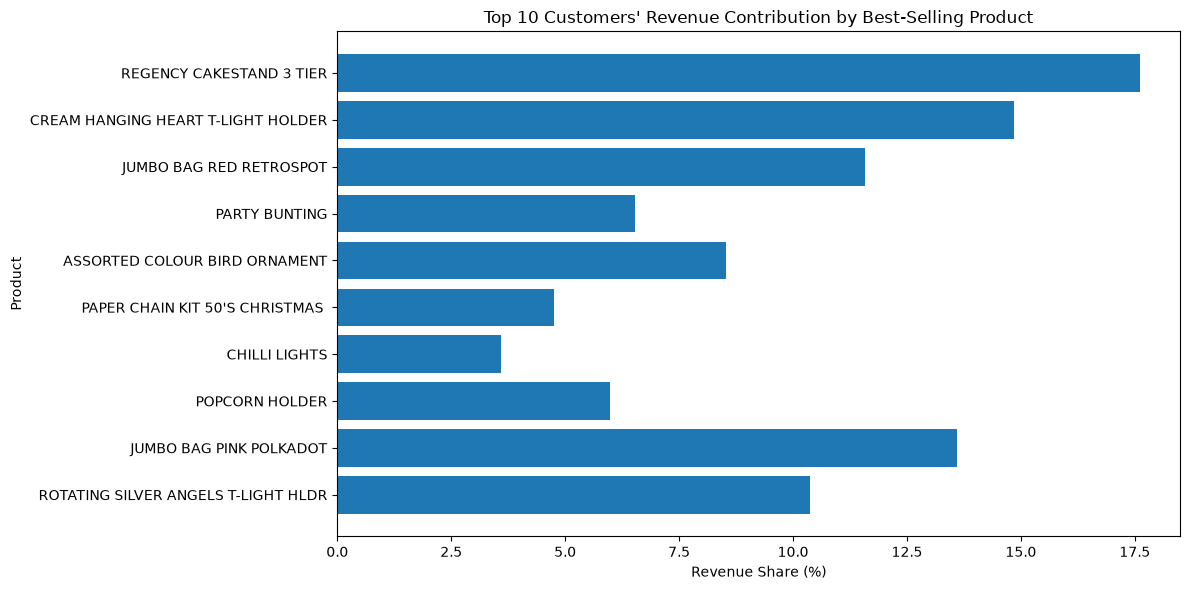

In [385]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_products_customer_contribution["Description"],
    top_products_customer_contribution["High-Value Revenue Share (%)"]
)

plt.xlabel("Revenue Share (%)")
plt.ylabel("Product")
plt.title("Top 10 Customers' Revenue Contribution by Best-Selling Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### Key Findings — Sales Concentration & Product Revenue Contribution

- The Top 10 highest-value customers generated approximately **£2.66 million in Net Spending**, representing **13.97% of total company Net Sales** (£19.00 million).
- Their contribution to the Top 10 best-selling products varied considerably, ranging from **3.59% to 17.61%** of each product's Net Sales.
- **REGENCY CAKESTAND 3 TIER** had the highest revenue contribution from these customers (**17.61%**), followed by **CREAM HANGING HEART T-LIGHT HOLDER** (**14.86%**) and **JUMBO BAG PINK POLKADOT** (**13.59%**).
- **CHILLI LIGHTS** had the lowest contribution (**3.59%**), suggesting that its revenue was more broadly distributed across other customers.
- Although **JUMBO BAG PINK POLKADOT** ranked ninth by overall Net Sales, it had the third-highest revenue share attributable to the Top 10 customers.

#### Business Insight

The Top 10 highest-value customers accounted for a meaningful share of overall revenue, highlighting the importance of customer retention and relationship management.

However, their influence was not uniform across best-selling products. Some products had a relatively high concentration of revenue from these customers, while others relied more heavily on the broader customer base.

These findings suggest that the business could benefit from targeted retention strategies for high-value customers, while maintaining broader marketing and sales efforts for products with more diversified demand.

The results also demonstrate that **product revenue rankings and customer revenue concentration provide complementary perspectives** on business performance.

## Final Conclusions — Business Performance Overview

### Overall Business Performance

The Online Retail II analysis examined sales performance, product demand, customer purchasing behavior, and revenue concentration across five business questions.

The company generated approximately **£20.47 million in Gross Sales**. After accounting for recorded cancellations of approximately **£1.46 million**, total **Net Sales reached £19.00 million**.

These results establish a baseline for evaluating business performance and demonstrate the importance of accounting for cancellations when measuring actual revenue.

### Product Performance & Customer Preferences

Product performance analysis revealed differences between revenue generation and sales volume.

**REGENCY CAKESTAND 3 TIER** was the highest-performing product by Net Sales, generating approximately **£314,045**, while **WORLD WAR 2 GLIDERS ASSTD DESIGNS** led in units sold, with **104,435 units**.

Among the Top 10 highest-value customers, **REGENCY CAKESTAND 3 TIER** was also the most frequently purchased product, appearing in **199 distinct invoices**. However, **PACK OF 72 RETROSPOT CAKE CASES** led in Net Units Purchased by these customers, with **20,376 units**.

These findings demonstrate that revenue, purchasing frequency, and unit volume capture different aspects of product performance. Evaluating these metrics together can support more informed inventory planning, product prioritization, and customer-focused marketing strategies.

The additional cancellation analysis revealed that none of the Top 10 products by net units sold appeared among the Top 10 products by cancelled units. However, two products ranked among both the Top 10 by Net Sales and the Top 10 by cancellation value: **REGENCY CAKESTAND 3 TIER** and **CREAM HANGING HEART T-LIGHT HOLDER**. Their cancellation values represented approximately **5.00%** and **3.64%** of their respective Gross Sales. These findings highlight the importance of evaluating cancellations relative to sales performance rather than relying solely on absolute cancellation amounts.

### Customer Value & Revenue Concentration

Customer analysis identified **Customer 18102** as the highest-value customer, generating approximately **£570,381 in Net Spending**.

Together, the Top 10 highest-value customers contributed approximately **£2.66 million**, representing **13.97% of total company Net Sales**.

Their contribution to individual best-selling products varied considerably. For example, these customers generated **17.61% of REGENCY CAKESTAND 3 TIER's Net Sales**, compared with only **3.59% of CHILLI LIGHTS' Net Sales**.

These findings highlight the commercial importance of high-value customers while demonstrating that their influence differs across products.

From a business perspective, customer retention strategies could help protect revenue generated by these customers, while broader customer acquisition and marketing initiatives could support products with more diversified demand.

### Strategic Recommendations

Based on the findings from the five business questions, the following actions could be considered:

**1. Strengthen High-Value Customer Retention**

Develop targeted relationship management and retention initiatives for high-value customers, who collectively account for 13.97% of total Net Sales.

**2. Optimize Product and Inventory Planning**

Consider both revenue performance and unit demand when prioritizing products and planning inventory. Products that lead in Net Sales may differ from those generating the highest sales volumes.

**3. Tailor Product Marketing to Customer Behavior**

Use purchasing frequency, unit quantities, and revenue contribution to identify products that may benefit from targeted promotions or customer-specific offers.

**4. Monitor Revenue Concentration**

Track changes in customer revenue concentration over time to better understand the business's exposure to its highest-value customers.

**5. Incorporate Cancellations into Performance Reporting**

Continue evaluating Net Sales alongside Gross Sales to avoid overstating revenue and better understand the financial impact of cancellations. Monitor product-level cancellation values relative to sales performance, while investigating unusually large transactions separately to avoid drawing misleading conclusions about product demand or customer satisfaction.

## Limitations & Next Steps

- **Customer identification:** Transactions without a `Customer ID` were included in overall sales metrics but could not be attributed to individual customers. Therefore, customer-level analyses only consider identifiable customers.
- **Geographic analysis:** This project did not explore sales performance by country or region. A geographic breakdown could help identify important markets and regional differences in purchasing behavior.
- **Time-series analysis:** Monthly sales trends were examined, but more detailed analyses of seasonality, promotional effects, and unusual fluctuations could provide additional insights.
- **Revenue versus profitability:** Net Sales account for recorded cancellations but do not represent profit, as product costs, operating expenses, and other financial adjustments were not analyzed.

**Next steps:** Expand the analysis to include geographic segmentation, customer retention patterns, and more detailed time-series comparisons.